<a href="https://colab.research.google.com/github/Emo4ka07/VKR/blob/main/NTP_%D0%90%D0%9A%D0%90%D0%A0_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# случайный процесс

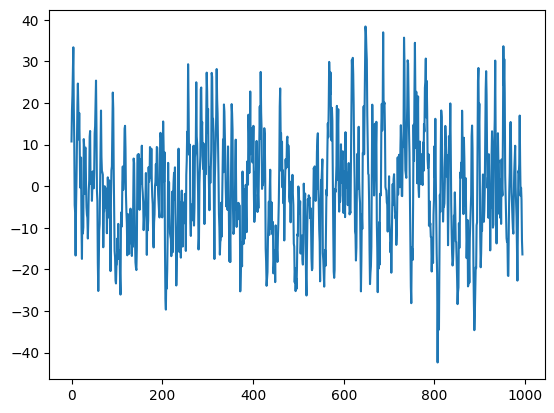

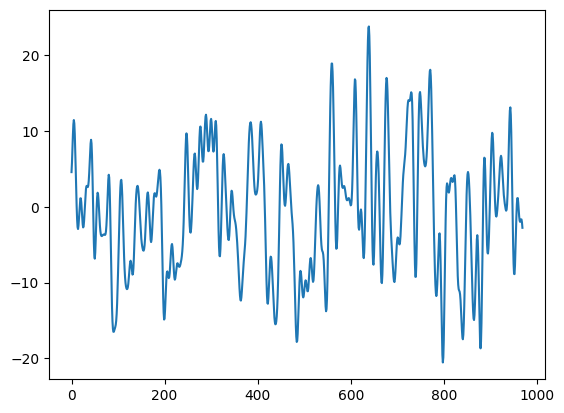

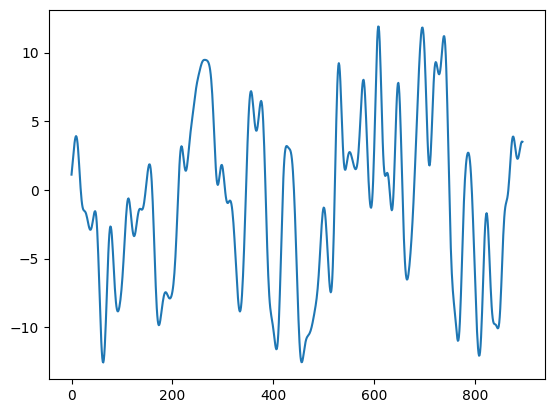

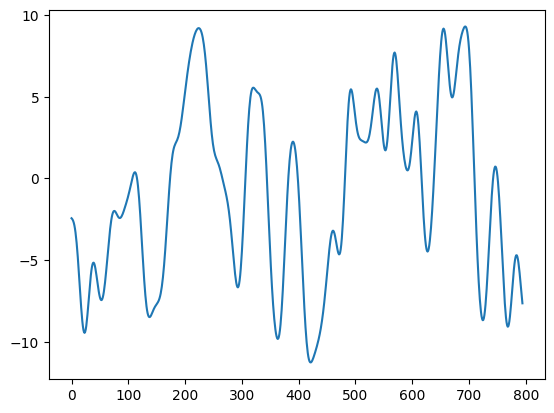

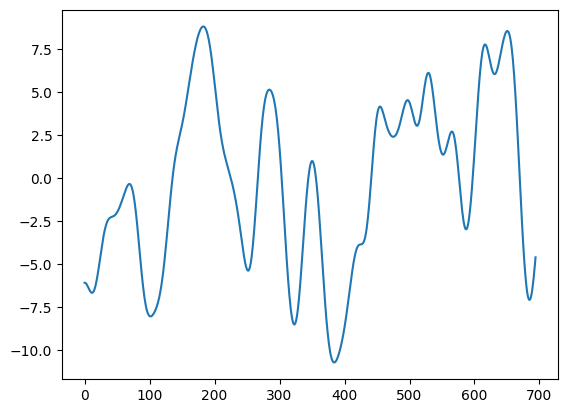

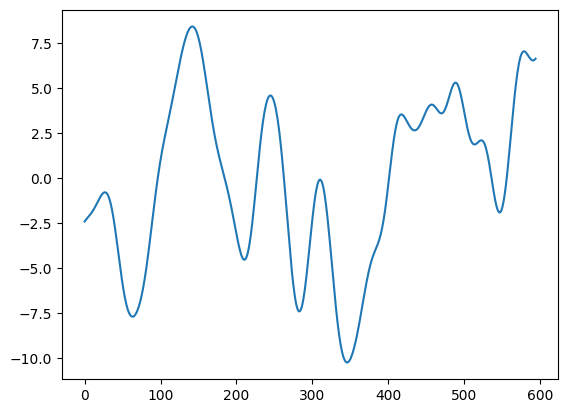

500


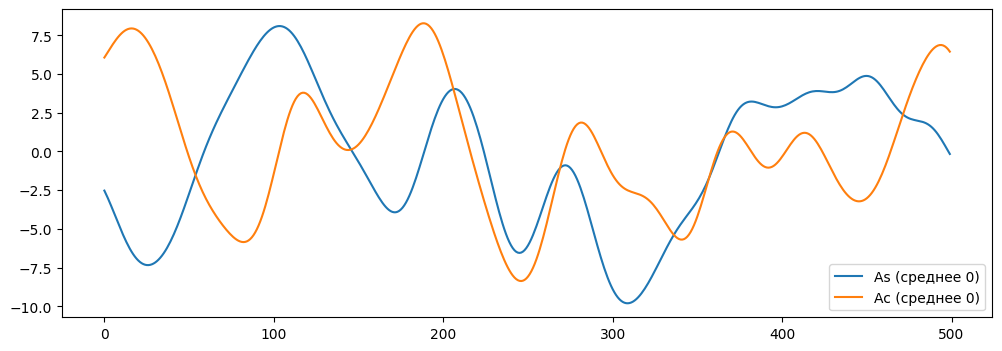

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from scipy.ndimage import uniform_filter1d

np.random.seed(13)

# ---------------- Параметры ----------------
n = 1000                # длина сигнала
cutoff = 0.02           # нормированная частота среза (0..0.5)
order = 4               # порядок фильтра
omega = 0.3 * 2*np.pi   # частота несущей
# -------------------------------------------

# Генерация нормальных As и Ac
As = np.random.normal(loc=0, scale=30, size=n)
Ac = np.random.normal(loc=0, scale=30, size=n)

for j in range(100):
    for i in range(len(As)-4):
            sums=0
            sumc=0
            for k in range(5):
                  sums += As[i+k]
                  sumc += Ac[i+k]
            As[i]=sums/5
            Ac[i]=sumc/5
    As = As[:-5]
    Ac = Ac[:-5]
    if (j%20 == 0) or (j == 5):
            plt.plot(As)
            plt.show()
print(len(As))

# Создание low-pass Butterworth фильтра
# b, a = butter(order, cutoff, btype='low')

# # Применение filtfilt (двусторонний фильтр)
# As_smooth = filtfilt(b, a, As)
# Ac_smooth = filtfilt(b, a, Ac)

# Функция сглаживания
# def smooth_signal(x, window_len=5, iterations=25):
#     for _ in range(iterations):
#         x = uniform_filter1d(x, size=window_len, mode='nearest')
#     return x

# Фильтр низких частот: скользящее среднее
# def smooth(x, window_len=5, iterations=10):
#     for _ in range(iterations):
#         x = np.convolve(x, np.ones(window_len)/window_len, mode='same')
#     return x

# As_smooth = smooth_signal(As, window_len=5, iterations=25)
# Ac_smooth = smooth_signal(Ac, window_len=5, iterations=25)

# Визуализация
plt.figure(figsize=(12,4))
plt.plot(As, label='As (среднее 0)')
plt.plot(Ac, label='Ac (среднее 0)')
plt.legend()
plt.show()


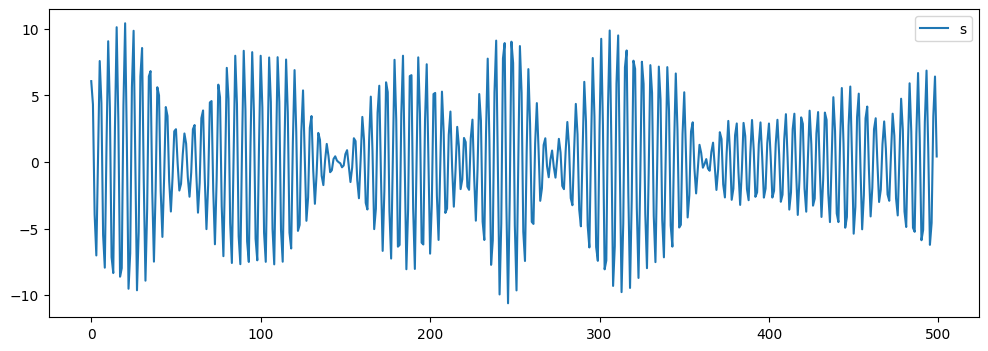

In [ ]:
t = np.arange(len(Ac))  # дискретное время
omega = 1.3

s = Ac * np.cos(omega * t) - As * np.sin(omega * t)

plt.figure(figsize=(12,4))
plt.plot(s, label='s')
plt.legend()
plt.show()

# случайный процесс 2

Дисперсия ξ(t): 237.52


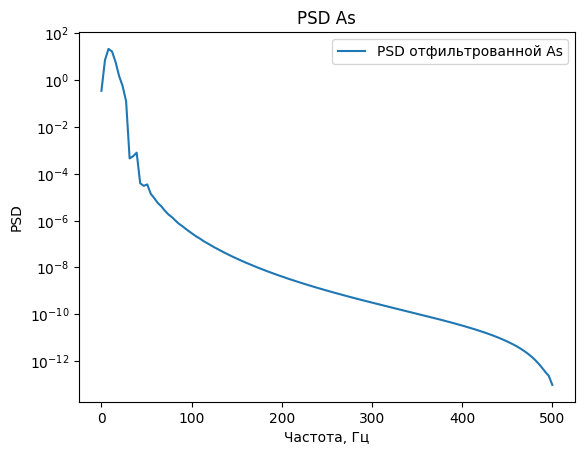

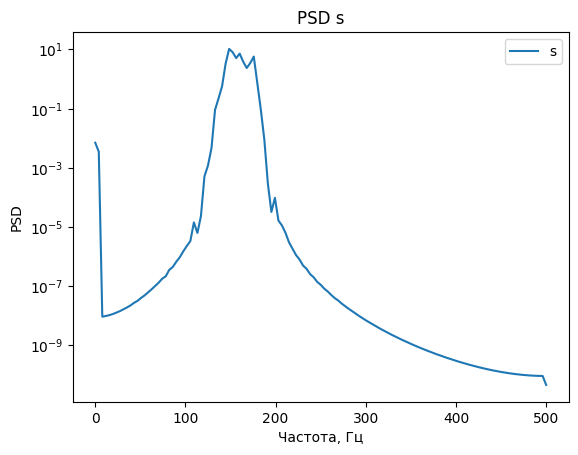

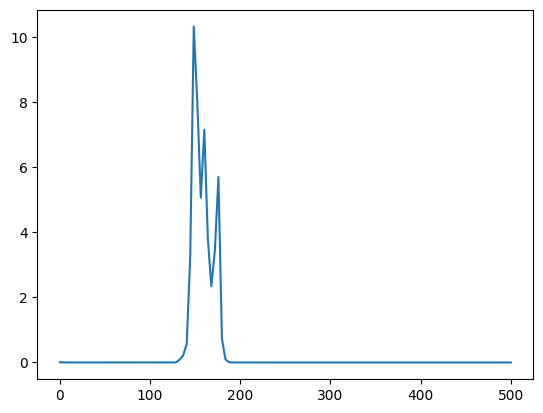

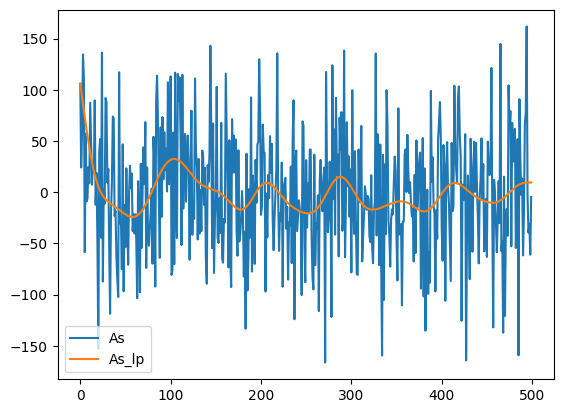

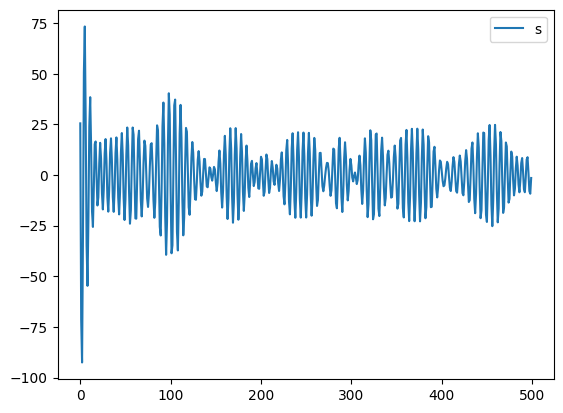

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, welch

np.random.seed(0)

n = 500
fs = 1000.0          # частота дискретизации (Гц)
cutoff = 20.0        # ширина полосы НЧ (Гц)
order = 4
# omega = 2 * np.pi * 100 / fs   # центральная частота (100 Гц в радианах/отсчет)
omega=1

# генерация случайных величин
As = np.random.normal(0, 60, n)
Ac = np.random.normal(0, 60, n)

# фильтр низких частот
b, a = butter(order, cutoff / (fs / 2), btype='low')

As_lp = filtfilt(b, a, As)
Ac_lp = filtfilt(b, a, Ac)

# получение s
t = np.arange(n)
s = Ac_lp * np.cos(omega * t) - As_lp * np.sin(omega * t)

# psd
f_As, psd_As = welch(As_lp, fs=fs, nperseg=256)
f_s, psd_s = welch(s, fs=fs, nperseg=256)

# оценка дисперсии после фильтрации
var_As_lp = np.var(As_lp)
var_Ac_lp = np.var(Ac_lp)
var_s = np.var(s)
print(f"Дисперсия ξ(t): {var_s:.2f}")

# графики
plt.figure()
plt.semilogy(f_As, psd_As, label='PSD отфильтрованной As')
plt.xlabel('Частота, Гц')
plt.ylabel('PSD')
plt.title('PSD As')
plt.legend()
plt.show()

plt.figure()
plt.semilogy(f_s, psd_s, label='s')
plt.xlabel('Частота, Гц')
plt.ylabel('PSD')
plt.title('PSD s')
plt.legend()
plt.show()

plt.plot(f_s, psd_s)
plt.show()

plt.plot(As, label='As')
plt.plot(As_lp, label='As_lp')
plt.legend()
plt.show()

plt.plot(s, label='s')
plt.legend()
plt.show()


# вывод управления

In [ ]:
import sympy
from sympy import *
from IPython.display import display, Math
init_printing()

u, EL, EL_1, T, T1, a1, b2, d, t = symbols('u EL EL_1 T T1 a1 b2 d t')
x1, x2, x3, a2, b1, d1, d2, w1, w2, K2, K1, r1, r2, m, m1, C, phi, d_phi, g1, g2 = symbols('x1 x2 x3 a2 b1 d1 d2 w1 w2 K2 K1 r1 r2 m m1 C phi d_phi g1 g2')

n = int(input("Сколько уравнений в системе? "))
print("Введите правые части уравнений")
F = [] # список уравнений

# добавляем уравнения в список
for i in range(n):
    f = sympify(input())
    F.append(f)
# по какому уравнению управление
for i in range(len(F)):
  if u in F[i].free_symbols:
    f_with_u=F[i] # правая часть уравнения, по котрому управление
    upr_k = i+1 # номер уравнения, по которому управление


# обработка цели
print("Введите цель. Например: x2 - C")
psi = sympify(input())

# получаем все свободные переменные в выражении
vars = psi.free_symbols

var_count = 0 # счетчик переменных
x_psi_list = [] # список переменных, по которым цель
d_list = [] # список номеров переменных, по которым цель

# проверяем каждый символ в выражении
for symbol in vars:
    var = str(symbol)  # преобразуем символ в строку
    if var.startswith('x'):  # если переменная начинается с 'x'
        try:
            d = int(var[1:])  # извлекаем число после 'x'
            d_list.append(d)
            x_psi_list.append(var)
            var_count += 1    # увеличиваем счетчик переменных
        except ValueError:
            print(f"Переменная '{var}' не соответствует формату 'xd' (после 'x' должно быть число)")

d_psi = 0

# vars.remove(St)
# vars.remove(A)
# vars.remove(P)

# производная от пси
for i in range(1, len(F)+1):
    d_psi2 = diff(psi, x2)

    xi = symbols(f"x{i}")
    d_psi_i = diff(psi, xi) * F[i-1]
    d_psi_i = d_psi_i.simplify()
    d_psi = d_psi + d_psi_i
    d_psi = d_psi.simplify()

if t in vars:
    d_psi += diff(psi, t)

print("d_psi =", d_psi)

# если управление и цель по одной переменной
if upr_k in d_list:
    print("Цель содержит переменную управления")

    EL=T*d_psi+psi
    EL=expand(EL)
    u=solve(EL, u)

    u = u[0]
    print("u = ")
    display(Math(latex(u)))

# если по разным переменным
else:
    print("Цель не содержит переменную управления")

    x_u = symbols(f"x{upr_k}")  # переменная, по которой управление
    psi_1 = x_u - phi

    d_psi_1 = diff(psi_1, x_u) * F[upr_k - 1] - d_phi
    EL_1 = T1 * d_psi_1 + psi_1

    print("EL_1 =", EL_1)

    # u как функция от phi и d_phi
    u_expr = solve(EL_1, u)[0]
    print("u(phi, d_phi) = ", u_expr)

    # Теперь EL = T*d_psi + psi, подставим x_u = phi
    EL = T * d_psi + psi
    EL = EL.subs(x_u, phi)

    print("EL = ", EL)

    # решаем относительно phi
    phi_expr = solve(EL, phi)[0]
    print("phi = ", phi_expr)

    # d_phi через x'
    d_phi_expr = 0
    for i in range(1, len(F) + 1):
        xi = symbols(f"x{i}")
        print("частные производные ", diff(phi_expr, xi))
        print("правые части x ", F[i - 1])
        d_phi_expr += diff(phi_expr, xi) * F[i - 1]

    print("d_phi = ", d_phi_expr)

    # финальное подставление
    u_final = u_expr.subs({phi: phi_expr, d_phi: d_phi_expr})
    u_final = simplify(u_final)

    print("u = ", u_final)
    display(Math(latex(u_final)))


Сколько уравнений в системе? 3
Введите правые части уравнений
r1 * x1 * (1 - (x1 + a1 * x2) / K1) - (w1 * x1 * x3)/(d1 + x1) + u
r2 * x2 * (1 - (x2 + a2 * x1)/K2) - (w2 * x2 *x3)/(d2 + b1 * x2 ** 2)
(g1 * x1 * x3)/(d1 + x1) - (g2 * x2 * x3)/(d2 + b1 * x2 ** 2) - m * x3 - m1 * x3 ** 2
Введите цель. Например: x2 - C
x2 - C
d_psi = -x2*(K2*w2*x3 + r2*(b1*x2**2 + d2)*(-K2 + a2*x1 + x2))/(K2*(b1*x2**2 + d2))
Цель не содержит переменную управления
EL_1 = T1*(-d_phi + r1*x1*(1 - (a1*x2 + x1)/K1) + u - w1*x1*x3/(d1 + x1)) - phi + x1
u(phi, d_phi) =  (K1*T1*d1*d_phi - K1*T1*d1*r1*x1 + K1*T1*d_phi*x1 - K1*T1*r1*x1**2 + K1*T1*w1*x1*x3 + K1*d1*phi - K1*d1*x1 + K1*phi*x1 - K1*x1**2 + T1*a1*d1*r1*x1*x2 + T1*a1*r1*x1**2*x2 + T1*d1*r1*x1**2 + T1*r1*x1**3)/(K1*T1*(d1 + x1))
EL =  -C + x2 - T*x2*(K2*w2*x3 + r2*(b1*x2**2 + d2)*(-K2 + a2*phi + x2))/(K2*(b1*x2**2 + d2))
phi =  (-C*K2*b1*x2**2 - C*K2*d2 + K2*T*b1*r2*x2**3 + K2*T*d2*r2*x2 - K2*T*w2*x2*x3 + K2*b1*x2**3 + K2*d2*x2 - T*b1*r2*x2**4 - T*d2*r2*x2*

<IPython.core.display.Math object>

## проверки

In [ ]:
x2_f=r2 * x2 * (1 - (x2 + a2 * x1)/K2) - (w2 * x2 *x3)/(d2 + b1 * x2 ** 2)
check= x2_f - d_psi
check=simplify(check)
display(Math(latex(check)))

<IPython.core.display.Math object>

In [ ]:
u_w_phi_my = d_phi - (r1 * x1 * (1 - (x1 + a1 * x2) / K1) - (w1 * x1 * x3)/(d1 + x1)) - (x1 - phi)/T1

check= u_w_phi_my - u_expr
check=simplify(check)
display(Math(latex(check)))

<IPython.core.display.Math object>

In [ ]:
EL_my = T* (r2 * x2 * (1 - (x2 + a2 * phi)/K2) - (w2 * x2 *x3)/(d2 + b1 * x2 ** 2)) + (x2 - C)

check= EL_my - EL
check=simplify(check)
display(Math(latex(check)))

<IPython.core.display.Math object>

In [ ]:
phi_my= (K2 * (1 - ((((w2 * x2 *x3)/(d2 + b1 * x2 ** 2)) - (x2 - C)/T)/(r2*x2))) - x2)/a2
check=phi_my-phi_expr
check=simplify(check)
display(Math(latex(check)))

<IPython.core.display.Math object>

In [ ]:
d_phi_ds = (
    (
        (-2*C*K2*b1*x2 + 3*K2*T*b1*r2*x2**2 + K2*T*d2*r2 - K2*T*w2*x3 + 3*K2*b1*x2**2 + K2*d2 - 4*T*b1*r2*x2**3 - 2*T*d2*r2*x2) * F[1] +
        (-K2*T*w2*x2) * F[2]
    ) * (T*a2*r2*x2*(b1*x2**2 + d2)) -
    (-C*K2*b1*x2**2 - C*K2*d2 + K2*T*b1*r2*x2**3 + K2*T*d2*r2*x2 - K2*T*w2*x2*x3 + K2*b1*x2**3 + K2*d2*x2 - T*b1*r2*x2**4 - T*d2*r2*x2**2) *
    (T*a2*r2*(3*b1*x2**2 + d2) * F[1])
) / (T*a2*r2*x2*(b1*x2**2 + d2))**2

check=d_phi_ds-d_phi_expr
check=simplify(check)
display(Math(latex(check)))

<IPython.core.display.Math object>

In [ ]:
u_final_ds = (K1*T1*d1*(
    (
        (-2*C*K2*b1*x2 + 3*K2*T*b1*r2*x2**2 + K2*T*d2*r2 - K2*T*w2*x3 + 3*K2*b1*x2**2 + K2*d2 - 4*T*b1*r2*x2**3 - 2*T*d2*r2*x2) *
        (r2 * x2 * (1 - (x2 + a2 * x1)/K2) - (w2 * x2 * x3)/(d2 + b1 * x2 ** 2)) +
        (-K2*T*w2*x2) *
        ((g1 * x1 * x3)/(d1 + x1) - (g2 * x2 * x3)/(d2 + b1 * x2 ** 2) - m * x3 - m1 * x3 ** 2)
    ) * (T*a2*r2*x2*(b1*x2**2 + d2)) -
    (-C*K2*b1*x2**2 - C*K2*d2 + K2*T*b1*r2*x2**3 + K2*T*d2*r2*x2 - K2*T*w2*x2*x3 + K2*b1*x2**3 + K2*d2*x2 - T*b1*r2*x2**4 - T*d2*r2*x2**2) *
    (T*a2*r2*(3*b1*x2**2 + d2) *
        (r2 * x2 * (1 - (x2 + a2 * x1)/K2) - (w2 * x2 * x3)/(d2 + b1 * x2 ** 2))
    )
) / (T*a2*r2*x2*(b1*x2**2 + d2))**2
- K1*T1*d1*r1*x1 + K1*T1*(
    (
        (-2*C*K2*b1*x2 + 3*K2*T*b1*r2*x2**2 + K2*T*d2*r2 - K2*T*w2*x3 + 3*K2*b1*x2**2 + K2*d2 - 4*T*b1*r2*x2**3 - 2*T*d2*r2*x2) *
        (r2 * x2 * (1 - (x2 + a2 * x1)/K2) - (w2 * x2 * x3)/(d2 + b1 * x2 ** 2)) +
        (-K2*T*w2*x2) *
        ((g1 * x1 * x3)/(d1 + x1) - (g2 * x2 * x3)/(d2 + b1 * x2 ** 2) - m * x3 - m1 * x3 ** 2)
    ) * (T*a2*r2*x2*(b1*x2**2 + d2)) -
    (-C*K2*b1*x2**2 - C*K2*d2 + K2*T*b1*r2*x2**3 + K2*T*d2*r2*x2 - K2*T*w2*x2*x3 + K2*b1*x2**3 + K2*d2*x2 - T*b1*r2*x2**4 - T*d2*r2*x2**2) *
    (T*a2*r2*(3*b1*x2**2 + d2) *
        (r2 * x2 * (1 - (x2 + a2 * x1)/K2) - (w2 * x2 * x3)/(d2 + b1 * x2 ** 2))
    )
) * x1 / (T*a2*r2*x2*(b1*x2**2 + d2))**2
- K1*T1*r1*x1**2 + K1*T1*w1*x1*x3 + K1*d1*(
    (-C*K2*b1*x2**2 - C*K2*d2 + K2*T*b1*r2*x2**3 + K2*T*d2*r2*x2 - K2*T*w2*x2*x3 + K2*b1*x2**3 + K2*d2*x2 - T*b1*r2*x2**4 - T*d2*r2*x2**2)/(T*a2*r2*x2*(b1*x2**2 + d2))
) - K1*d1*x1 + K1*(
    (-C*K2*b1*x2**2 - C*K2*d2 + K2*T*b1*r2*x2**3 + K2*T*d2*r2*x2 - K2*T*w2*x2*x3 + K2*b1*x2**3 + K2*d2*x2 - T*b1*r2*x2**4 - T*d2*r2*x2**2)/(T*a2*r2*x2*(b1*x2**2 + d2))
) * x1 - K1*x1**2 + T1*a1*d1*r1*x1*x2 + T1*a1*r1*x1**2*x2 + T1*d1*r1*x1**2 + T1*r1*x1**3) / (K1*T1*(d1 + x1))

check=u_final_ds-u_final
check=simplify(check)
display(Math(latex(check)))

<IPython.core.display.Math object>

In [ ]:
St, A, P = symbols('St A P')
phi_my = K2* (r2*x2 - w2*x2*x3/(d2+b1*x2**2) - 2*A*pi/P * cos(2*pi*t/P) + (x2 - (St + A*sin(2*pi*t/P))) / T) / (r2*x2**2*a2)
display(Math(latex(phi_my)))

display(Math(latex(phi_expr)))

check=phi_my-phi_expr
check=simplify(check)
display(Math(latex(check)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [ ]:
u_my = -(x1 - phi)/T1 + d_phi - (r1 * x1 * (1 - (x1 + a1 * x2) / K1) - (w1 * x1 * x3)/(d1 + x1))
display(Math(latex(u_my)))

ch=u_my-u_expr
ch=simplify(ch)
display(Math(latex(ch)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

u для C - const

In [ ]:
u_const = u[0]

In [ ]:
display(Math(latex(u_const)))

<IPython.core.display.Math object>

# вывод управления функция + хардкод системы уравнений

In [17]:
import numpy as np
import sympy
from sympy import symbols, sympify, diff, expand, solve, simplify, init_printing, latex, sin, cos, pi, Eq, Matrix # Explicitly import common functions
from IPython.display import display, Math

def compute_u(upr_k, psi_str):
    init_printing()

    # Define all symbols in one go
    all_symbols_str = 'u EL EL_1 T T1 a1 b2 d t x1 x2 x3 a2 b1 d1 d2 w1 w2 K2 K1 r1 r2 m m1 C phi d_phi g1 g2 S A P'
    all_symbols = symbols(all_symbols_str)

    # Create a dictionary mapping symbol names to symbol objects
    custom_global_dict = {str(s): s for s in all_symbols}

    # Add commonly used sympy functions to this custom global_dict
    # This is crucial to prevent sympify from trying to do `from sympy import *` internally
    custom_global_dict['sin'] = sympy.sin
    custom_global_dict['cos'] = sympy.cos
    custom_global_dict['pi'] = sympy.pi
    custom_global_dict['Eq'] = sympy.Eq
    custom_global_dict['Matrix'] = sympy.Matrix
    custom_global_dict['symbols'] = sympy.symbols
    custom_global_dict['sympify'] = sympy.sympify
    custom_global_dict['diff'] = sympy.diff
    custom_global_dict['expand'] = sympy.expand
    custom_global_dict['solve'] = sympy.solve
    custom_global_dict['simplify'] = sympy.simplify
    custom_global_dict['latex'] = sympy.latex

    # Assign symbols for clarity in the rest of the function (optional but good practice)
    u, EL, EL_1, T, T1, a1, b2, d, t, x1, x2, x3, a2, b1, d1, d2, w1, w2, K2, K1, r1, r2, m, m1, C, phi, d_phi, g1, g2, S, A, P = all_symbols

    F = []

    # Pass custom_global_dict as global_dict to sympify
    F.append(
        sympify("r1*x1*(1 - (x1 + a1*x2)/K1) - w1*x1*x3/(d1 + x1)", global_dict=custom_global_dict)
    )

    F.append(
        sympify("r2*x2*(1 - (x2 + a2*x1)/K2) - w2*x2*x3/(d2 + b1*x2**2)", global_dict=custom_global_dict)
    )

    F.append(
        sympify("g1*x1*x3/(d1 + x1) - g2*x2*x3/(d2 + b1*x2**2) - m*x3 - m1*x3**2", global_dict=custom_global_dict)
    )

    F[upr_k - 1] = F[upr_k - 1] + u

    f_with_u = F[upr_k - 1]

    # чтение цели
    psi = sympify(psi_str, global_dict=custom_global_dict)
    vars = psi.free_symbols

    d_list = []
    for symbol in vars:
        var = str(symbol)
        if var.startswith("x"):
            try:
                d_list.append(int(var[1:]))
            except:
                pass

    # вычисление производной пси
    d_psi = 0
    for i in range(1, len(F) + 1):
        xi = symbols(f"x{i}") # No global_dict needed here, symbols is explicit
        d_psi_i = diff(psi, xi) * F[i - 1]
        d_psi += d_psi_i.simplify()
    if t in vars:
        d_psi += diff(psi, t)

    # если цель содержит переменную управления
    if upr_k in d_list:
        EL = T * d_psi + psi
        EL = expand(EL)
        u_expr = solve(EL, u)[0]
        return simplify(u_expr)

    # если не содержит
    x_u = symbols(f"x{upr_k}") # No global_dict needed here
    psi_1 = x_u - phi

    d_psi_1 = diff(psi_1, x_u) * F[upr_k - 1] - d_phi
    EL_1 = T1 * d_psi_1 + psi_1

    # u(phi, d_phi)
    u_expr = solve(EL_1, u)[0]

    # фи из уравнения Эйлера–Лагранжа
    EL = T * d_psi + psi
    EL = EL.subs(x_u, phi)
    phi_expr = solve(EL, phi)[0]

    # производная фи
    d_phi_expr = 0
    for i in range(1, len(F) + 1):
        xi = symbols(f"x{i}") # No global_dict needed here
        d_phi_expr += diff(phi_expr, xi) * F[i - 1]

    # финальное управление
    u_final = u_expr.subs({phi: phi_expr, d_phi: d_phi_expr})
    return simplify(u_final)

In [19]:
print(sympy.__version__)

1.14.0


## пересчет упавления

Первое управление вычислено
Начало пересчета управления
Второе управление вычислено


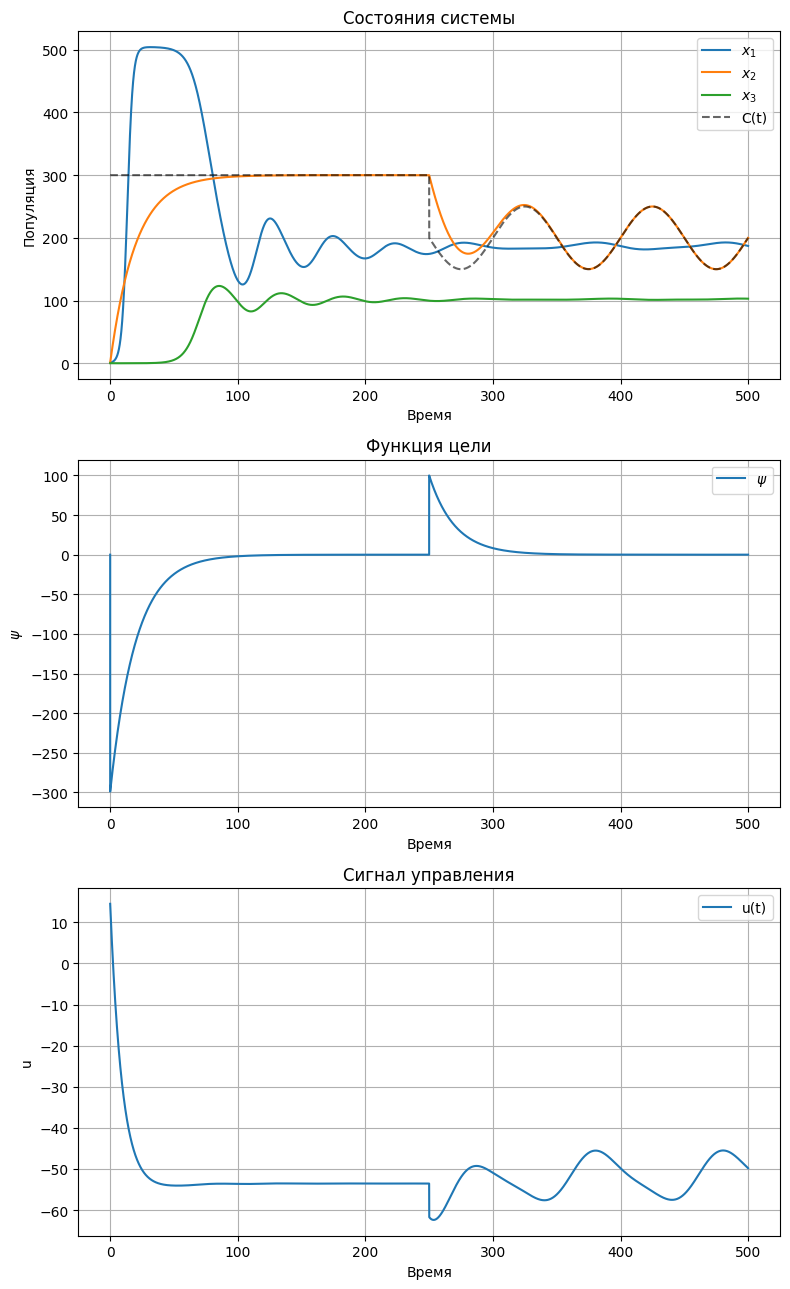

In [ ]:
from sympy import symbols, lambdify, sin, cos, pi
import matplotlib.pyplot as plt
import numpy as np

x1_sym, x2_sym, x3_sym = symbols('x1 x2 x3')
T, T1, a1, a2, b1 = symbols('T T1 a1 a2 b1')
St, A, P = symbols('St A P')
r1, r2, K1, K2, w1, w2, d1, d2, g1, g2, m, m1 = symbols(
    'r1 r2 K1 K2 w1 w2 d1 d2 g1 g2 m m1'
)
t_sym = symbols('t')

possible_vars = [
    x1_sym, x2_sym, x3_sym,
    T, T1, a1, a2, b1,
    St, A, P,
    r1, r2, K1, K2, w1, w2, d1, d2, g1, g2, m, m1,
    t_sym
]

values_dict = {
    x1_sym: 1,
    x2_sym: 1,
    x3_sym: 0.1,
    T: 20,
    T1: 20,
    a1: 0.002,
    a2: 0.001,
    b1: 0.49,
    r1: 0.4632,
    r2: 0.4425,
    K1: 505,
    K2: 505,
    w1: 0.6625,
    w2: 0.435,
    d1: 45,
    d2: 30,
    g1: 0.516,
    g2: 0.45,
    m: 0.309,
    m1: 0.001,
    St: 300, A: 100, P: 200,
    t_sym: 0
}

St2 = 200
A2 = 50
P2 = 100

dt = 0.01
t = np.arange(0, 500, dt)
x1_vals = np.zeros_like(t)
x2_vals = np.zeros_like(t)
x3_vals = np.zeros_like(t)
u_vals = np.zeros_like(t)
C_vals = np.zeros_like(t)
psi_vals = np.zeros_like(t)

x1_vals[0] = 1
x2_vals[0] = 1
x3_vals[0] = 0.1

# первое вычисление управления
psi_str_1 = "x2 - 300"   # первая цель

u_expr1 = compute_u(upr_k=2, psi_str=psi_str_1)
print("Первое управление вычислено")
used_vars1 = [v for v in possible_vars if v in u_expr1.free_symbols]
u_func1 = lambdify(used_vars1, u_expr1, modules='numpy')

u_func2 = None
psi_str_2 = "x2 - (St + A*sin(2*pi*t/P))"


# функция цели C(t)
def C_time(t):
    if t < 250:
        return 300
    else:
        return St2 + A2*np.sin(2*np.pi*t/P2)

for i in range(1, len(t)):
    current_time = t[i-1]

    values_dict[x1_sym] = x1_vals[i-1]
    values_dict[x2_sym] = x2_vals[i-1]
    values_dict[x3_sym] = x3_vals[i-1]
    values_dict[t_sym] = current_time

    if current_time < 250:
        C_vals[i-1] = C_time(current_time)
        args = [values_dict[v] for v in used_vars1]
        u_vals[i-1] = u_func1(*args)

    else:
        # пересчет управления
        if u_func2 is None:
            values_dict[St] = St2
            values_dict[A] = A2
            values_dict[P] = P2

            print("Начало пересчета управления")
            u_expr2 = compute_u(upr_k=2, psi_str=psi_str_2)
            print("Второе управление вычислено")
            used_vars2 = [v for v in possible_vars if v in u_expr2.free_symbols]
            u_func2 = lambdify(used_vars2, u_expr2, modules='numpy')

        # values for C(t)
        values_dict[St] = St2
        values_dict[A] = A2
        values_dict[P] = P2
        C_vals[i-1] = C_time(current_time)

        args = [values_dict[v] for v in used_vars2]
        u_vals[i-1] = u_func2(*args)

    # MODEL
    if current_time < 250:
        dx1 = values_dict[r1]*x1_vals[i-1]*(1 - (x1_vals[i-1] + values_dict[a1]*x2_vals[i-1])/values_dict[K1]) \
              - values_dict[w1]*x1_vals[i-1]*x3_vals[i-1]/(values_dict[d1] + x1_vals[i-1])


        dx2 = values_dict[r2]*x2_vals[i-1]*(1 - (x2_vals[i-1] + values_dict[a2]*x1_vals[i-1])/values_dict[K2]) \
              - values_dict[w2]*x2_vals[i-1]*x3_vals[i-1]/(values_dict[d2] + values_dict[b1]*x2_vals[i-1]**2) \
              + u_vals[i-1]

        dx3 = (values_dict[g1]*x1_vals[i-1]*x3_vals[i-1]/(values_dict[d1] + x1_vals[i-1])
              - values_dict[g2]*x2_vals[i-1]*x3_vals[i-1]/(values_dict[d2] + values_dict[b1]*x2_vals[i-1]**2)
              - values_dict[m]*x3_vals[i-1]
              - values_dict[m1]*x3_vals[i-1]**2)
    else:
        dx1 = values_dict[r1]*x1_vals[i-1]*(1 - (x1_vals[i-1] + values_dict[a1]*x2_vals[i-1])/values_dict[K1]) \
              - values_dict[w1]*x1_vals[i-1]*x3_vals[i-1]/(values_dict[d1] + x1_vals[i-1])


        dx2 = values_dict[r2]*x2_vals[i-1]*(1 - (x2_vals[i-1] + values_dict[a2]*x1_vals[i-1])/values_dict[K2]) \
              - values_dict[w2]*x2_vals[i-1]*x3_vals[i-1]/(values_dict[d2] + values_dict[b1]*x2_vals[i-1]**2)\
              + u_vals[i-1]

        dx3 = (values_dict[g1]*x1_vals[i-1]*x3_vals[i-1]/(values_dict[d1] + x1_vals[i-1])
              - values_dict[g2]*x2_vals[i-1]*x3_vals[i-1]/(values_dict[d2] + values_dict[b1]*x2_vals[i-1]**2)
              - values_dict[m]*x3_vals[i-1]
              - values_dict[m1]*x3_vals[i-1]**2)

    x1_vals[i] = max(0, x1_vals[i-1] + dx1*dt)
    x2_vals[i] = max(0, x2_vals[i-1] + dx2*dt)
    x3_vals[i] = max(0, x3_vals[i-1] + dx3*dt)

    if current_time < 250:
        psi_vals[i] = x2_vals[i] - C_vals[i-1]
    else:
        psi_vals[i] = x2_vals[i] - (values_dict[St] + values_dict[A]*np.sin(2*np.pi*current_time/values_dict[P]))



# последние значения
if u_func2:
    u_vals[-1] = u_func2(*[values_dict[v] for v in used_vars2])
else:
    u_vals[-1] = u_func1(*[values_dict[v] for v in used_vars1])
C_vals[-1] = C_time(t[-1])


# графики
plt.figure(figsize=(8,13))
plt.subplot(3,1,1)
plt.plot(t, x1_vals, label=r'$x_1$')
plt.plot(t, x2_vals, label=r'$x_2$')
plt.plot(t, x3_vals, label=r'$x_3$')
plt.plot(t, C_vals, color='black', linestyle='--', alpha=0.6, label='C(t)')
plt.legend(); plt.grid()
plt.title("Состояния системы")
plt.xlabel('Время')
plt.ylabel('Популяция')

plt.subplot(3,1,2)
plt.plot(t, psi_vals, label=r'$\psi$')
plt.legend(); plt.grid()
plt.title("Функция цели")
plt.xlabel('Время')
plt.ylabel(r'$\psi$')

plt.subplot(3,1,3)
plt.plot(t, u_vals, label='u(t)')
plt.legend(); plt.grid()
plt.title("Сигнал управления")
plt.xlabel('Время')
plt.ylabel('u')

plt.tight_layout()
plt.show()


# Шум

## шумит на x1, цель и управление там же

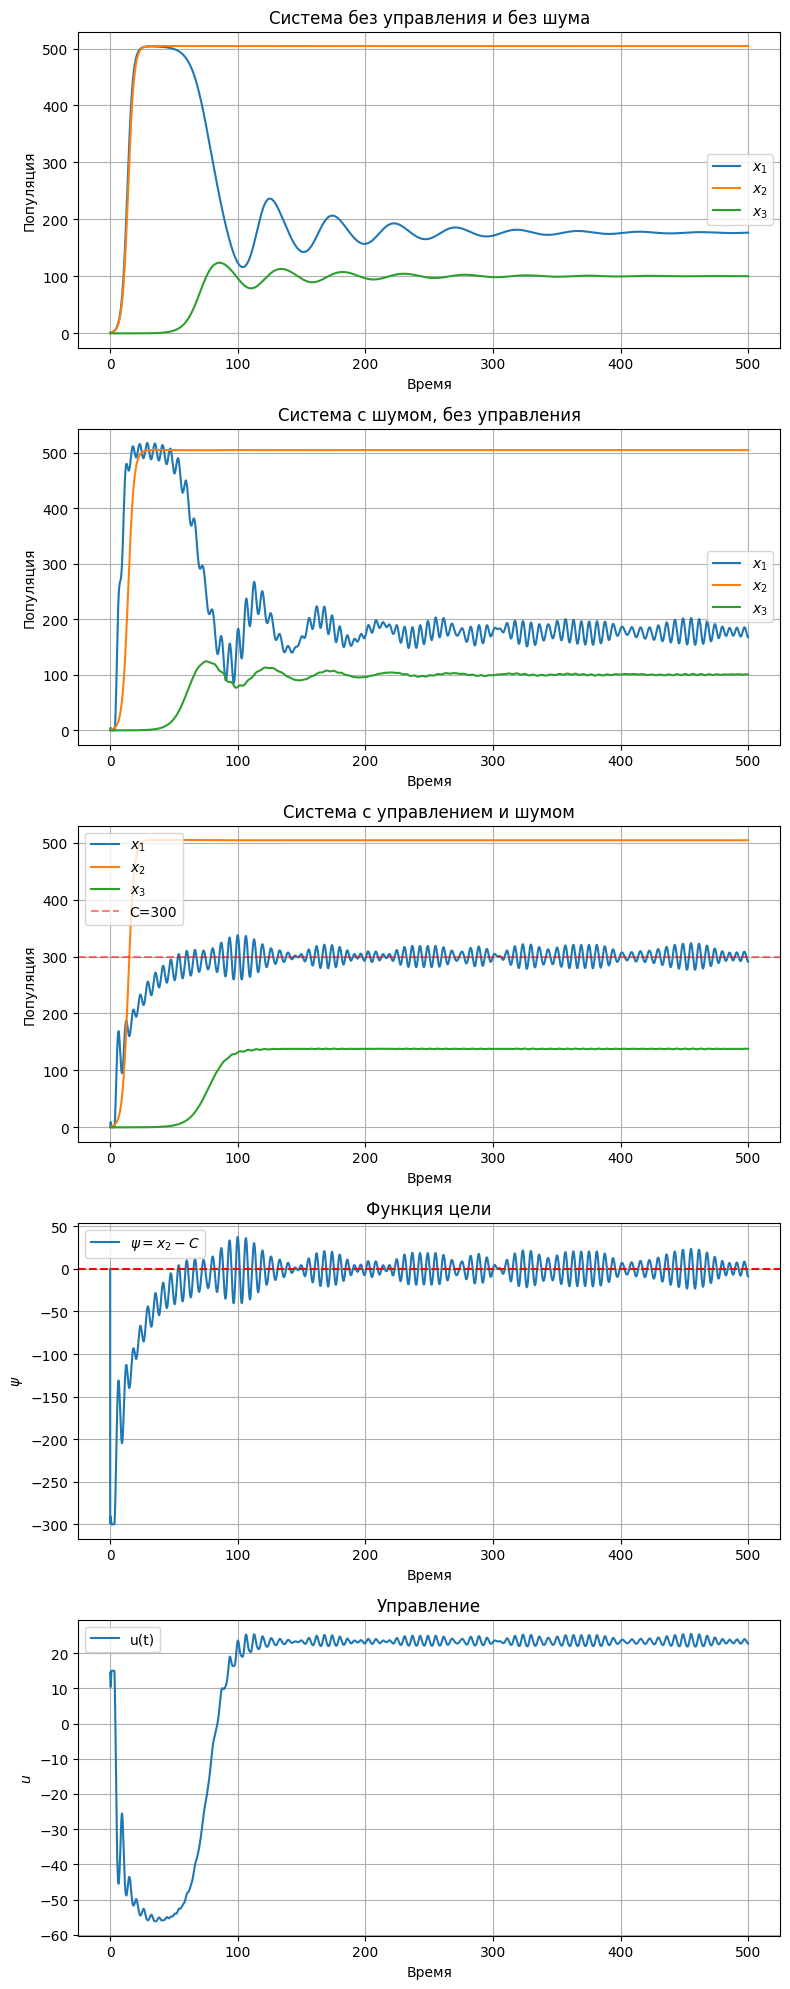

In [ ]:
from sympy import symbols, lambdify, sin, sympify
import numpy as np
import matplotlib.pyplot as plt

# Определяем символы
x1_sym, x2_sym, x3_sym, T, T1, a1, a2, b1, r1, r2, K1, K2, w1, w2, d1, d2, g1, g2, m, m1, C, t_sym = symbols(
    'x1 x2 x3 T T1 a1 a2 b1 r1 r2 K1 K2 w1 w2 d1 d2 g1 g2 m m1 C t'
)

possible_vars = [x1_sym, x2_sym, x3_sym, T, T1, a1, a2, b1, r1, r2, K1, K2,
                 w1, w2, d1, d2, g1, g2, m, m1, t_sym, C]

# Параметры
values_dict = {
    x1_sym: 1,
    x2_sym: 1,
    x3_sym: 0.1,
    T: 20,
    T1: 20,
    a1: 0.002,
    a2: 0.001,
    b1: 0.49,
    r1: 0.4632,
    r2: 0.4425,
    K1: 505,
    K2: 505,
    w1: 0.6625,
    w2: 0.435,
    d1: 45,
    d2: 30,
    g1: 0.516,
    g2: 0.45,
    m: 0.309,
    m1: 0.001,
    t_sym: 0.0,
    C: 300
}

# Время и шаг
dt = 0.01
t = np.arange(0, 500, dt)

t_s_original = np.linspace(0, t[-1], len(s), endpoint=True)

s_interp = np.interp(t, t_s_original, s)

# Массивы для хранения значений
x1_no_control_no_noise = np.zeros_like(t)
x2_no_control_no_noise = np.zeros_like(t)
x3_no_control_no_noise = np.zeros_like(t)

x1_no_control_with_noise = np.zeros_like(t)
x2_no_control_with_noise = np.zeros_like(t)
x3_no_control_with_noise = np.zeros_like(t)

x1_with_control = np.zeros_like(t)
x2_with_control = np.zeros_like(t)
x3_with_control = np.zeros_like(t)

u_vals = np.zeros_like(t)
psi_vals = np.zeros_like(t)

# Начальные условия
x1_no_control_no_noise[0] = 1
x2_no_control_no_noise[0] = 1
x3_no_control_no_noise[0] = 0.1

x1_no_control_with_noise[0] = 1
x2_no_control_with_noise[0] = 1
x3_no_control_with_noise[0] = 0.1

x1_with_control[0] = 1
x2_with_control[0] = 1
x3_with_control[0] = 0.1

# Шум
s_interp = np.interp(t, t_s_original, s)  # Интерполируем шум на сетку t

# Вычисляем управление
psi_str = "x1 - C"
u_expr = compute_u(upr_k=1, psi_str=psi_str)
used_vars = [v for v in possible_vars if v in u_expr.free_symbols]
u_func = lambdify(used_vars, u_expr, modules='numpy')

# Моделирование без управления и без шума
for i in range(1, len(t)):
    current_time = t[i-1]
    values_dict[t_sym] = current_time

    values_dict[x1_sym] = x1_no_control_no_noise[i-1]
    values_dict[x2_sym] = x2_no_control_no_noise[i-1]
    values_dict[x3_sym] = x3_no_control_no_noise[i-1]

    # Модель без управления и без шума
    dx1 = (
        values_dict[r1] * x1_no_control_no_noise[i-1] * (1 - (x1_no_control_no_noise[i-1] + values_dict[a1] * x2_no_control_no_noise[i-1]) / values_dict[K1])
        - (values_dict[w1] * x1_no_control_no_noise[i-1] * x3_no_control_no_noise[i-1]) / (values_dict[d1] + x1_no_control_no_noise[i-1])
    )

    dx2 = (
        values_dict[r2] * x2_no_control_no_noise[i-1] * (1 - (x2_no_control_no_noise[i-1] + values_dict[a2] * x1_no_control_no_noise[i-1]) / values_dict[K2])
        - (values_dict[w2] * x2_no_control_no_noise[i-1] * x3_no_control_no_noise[i-1]) / (values_dict[d2] + values_dict[b1] * x2_no_control_no_noise[i-1] ** 2)
    )

    dx3 = (
        (values_dict[g1] * x1_no_control_no_noise[i-1] * x3_no_control_no_noise[i-1]) / (values_dict[d1] + x1_no_control_no_noise[i-1])
        - (values_dict[g2] * x2_no_control_no_noise[i-1] * x3_no_control_no_noise[i-1]) / (values_dict[d2] + values_dict[b1] * x2_no_control_no_noise[i-1] ** 2)
        - values_dict[m] * x3_no_control_no_noise[i-1]
        - values_dict[m1] * x3_no_control_no_noise[i-1] ** 2
    )

    x1_no_control_no_noise[i] = max(0, x1_no_control_no_noise[i-1] + dx1 * dt)
    x2_no_control_no_noise[i] = max(0, x2_no_control_no_noise[i-1] + dx2 * dt)
    x3_no_control_no_noise[i] = max(0, x3_no_control_no_noise[i-1] + dx3 * dt)

# Моделирование с шумом, без управления
for i in range(1, len(t)):
    current_time = t[i-1]
    values_dict[t_sym] = current_time

    values_dict[x1_sym] = x1_no_control_with_noise[i-1]
    values_dict[x2_sym] = x2_no_control_with_noise[i-1]
    values_dict[x3_sym] = x3_no_control_with_noise[i-1]

    # Модель с шумом, без управления
    dx1 = (
        values_dict[r1] * x1_no_control_with_noise[i-1] * (1 - (x1_no_control_with_noise[i-1] + values_dict[a1] * x2_no_control_with_noise[i-1]) / values_dict[K1])
        - (values_dict[w1] * x1_no_control_with_noise[i-1] * x3_no_control_with_noise[i-1]) / (values_dict[d1] + x1_no_control_with_noise[i-1])
        + s_interp[i]  # Добавление шума
    )

    dx2 = (
        values_dict[r2] * x2_no_control_with_noise[i-1] * (1 - (x2_no_control_with_noise[i-1] + values_dict[a2] * x1_no_control_with_noise[i-1]) / values_dict[K2])
        - (values_dict[w2] * x2_no_control_with_noise[i-1] * x3_no_control_with_noise[i-1]) / (values_dict[d2] + values_dict[b1] * x2_no_control_with_noise[i-1] ** 2)

    )

    dx3 = (
        (values_dict[g1] * x1_no_control_with_noise[i-1] * x3_no_control_with_noise[i-1]) / (values_dict[d1] + x1_no_control_with_noise[i-1])
        - (values_dict[g2] * x2_no_control_with_noise[i-1] * x3_no_control_with_noise[i-1]) / (values_dict[d2] + values_dict[b1] * x2_no_control_with_noise[i-1] ** 2)
        - values_dict[m] * x3_no_control_with_noise[i-1]
        - values_dict[m1] * x3_no_control_with_noise[i-1] ** 2
    )

    x1_no_control_with_noise[i] = max(0, x1_no_control_with_noise[i-1] + dx1 * dt)
    x2_no_control_with_noise[i] = max(0, x2_no_control_with_noise[i-1] + dx2 * dt)
    x3_no_control_with_noise[i] = max(0, x3_no_control_with_noise[i-1] + dx3 * dt)

# Моделирование с управлением и шумом
for i in range(1, len(t)):
    current_time = t[i-1]
    values_dict[t_sym] = current_time

    values_dict[x1_sym] = x1_with_control[i-1]
    values_dict[x2_sym] = x2_with_control[i-1]
    values_dict[x3_sym] = x3_with_control[i-1]

    # Вычисляем управление
    args = [values_dict[v] for v in used_vars]
    u_vals[i-1] = u_func(*args)

    # Модель с управлением и шумом
    dx1 = (
        values_dict[r1] * x1_with_control[i-1] * (1 - (x1_with_control[i-1] + values_dict[a1] * x2_with_control[i-1]) / values_dict[K1])
        - (values_dict[w1] * x1_with_control[i-1] * x3_with_control[i-1]) / (values_dict[d1] + x1_with_control[i-1])
        + u_vals[i-1]
        + s_interp[i]  # Добавление шума
    )

    dx2 = (
        values_dict[r2] * x2_with_control[i-1] * (1 - (x2_with_control[i-1] + values_dict[a2] * x1_with_control[i-1]) / values_dict[K2])
        - (values_dict[w2] * x2_with_control[i-1] * x3_with_control[i-1]) / (values_dict[d2] + values_dict[b1] * x2_with_control[i-1] ** 2)

    )

    dx3 = (
        (values_dict[g1] * x1_with_control[i-1] * x3_with_control[i-1]) / (values_dict[d1] + x1_with_control[i-1])
        - (values_dict[g2] * x2_with_control[i-1] * x3_with_control[i-1]) / (values_dict[d2] + values_dict[b1] * x2_with_control[i-1] ** 2)
        - values_dict[m] * x3_with_control[i-1]
        - values_dict[m1] * x3_with_control[i-1] ** 2
    )

    x1_with_control[i] = max(0, x1_with_control[i-1] + dx1 * dt)
    x2_with_control[i] = max(0, x2_with_control[i-1] + dx2 * dt)
    x3_with_control[i] = max(0, x3_with_control[i-1] + dx3 * dt)

    psi_vals[i] = x1_with_control[i] - values_dict[C]

# Последние значения
values_dict[x1_sym] = x1_with_control[-1]
values_dict[x2_sym] = x2_with_control[-1]
values_dict[x3_sym] = x3_with_control[-1]
args = [values_dict[v] for v in used_vars]
u_vals[-1] = u_func(*args)

# Графики
plt.figure(figsize=(8, 20))

# 1. Без управления и без шума
plt.subplot(5, 1, 1)
plt.plot(t, x1_no_control_no_noise, label=r'$x_1$')
plt.plot(t, x2_no_control_no_noise, label=r'$x_2$')
plt.plot(t, x3_no_control_no_noise, label=r'$x_3$')
plt.title('Система без управления и без шума')
plt.xlabel('Время')
plt.ylabel('Популяция')
plt.legend()
plt.grid()

# 2. С шумом, но без управления
plt.subplot(5, 1, 2)
plt.plot(t, x1_no_control_with_noise, label=r'$x_1$')
plt.plot(t, x2_no_control_with_noise, label=r'$x_2$')
plt.plot(t, x3_no_control_with_noise, label=r'$x_3$')
plt.title('Система с шумом, без управления')
plt.xlabel('Время')
plt.ylabel('Популяция')
plt.legend()
plt.grid()

# 3. С управлением и шумом
plt.subplot(5, 1, 3)
plt.plot(t, x1_with_control, label=r'$x_1$')
plt.plot(t, x2_with_control, label=r'$x_2$')
plt.plot(t, x3_with_control, label=r'$x_3$')
plt.axhline(y=300, color='r', linestyle='--', alpha=0.5, label='C=300')
plt.title('Система с управлением и шумом')
plt.xlabel('Время')
plt.ylabel('Популяция')
plt.legend()
plt.grid()

# 4. График функции цели
plt.subplot(5, 1, 4)
plt.plot(t, psi_vals, label=r'$\psi = x_2 - C$')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Функция цели')
plt.xlabel('Время')
plt.ylabel(r'$\psi$')
plt.legend()
plt.grid()

# 5. Управление
plt.subplot(5, 1, 5)
plt.plot(t, u_vals, label='u(t)')
plt.xlabel('Время')
plt.ylabel(r'$u$')
plt.title('Управление')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


## цель случайный процесс

Последние значения
x1: 180.93662873172715
x2: 299.55357266090317
x3: 101.13976399889629
psi: 1.01498347789925


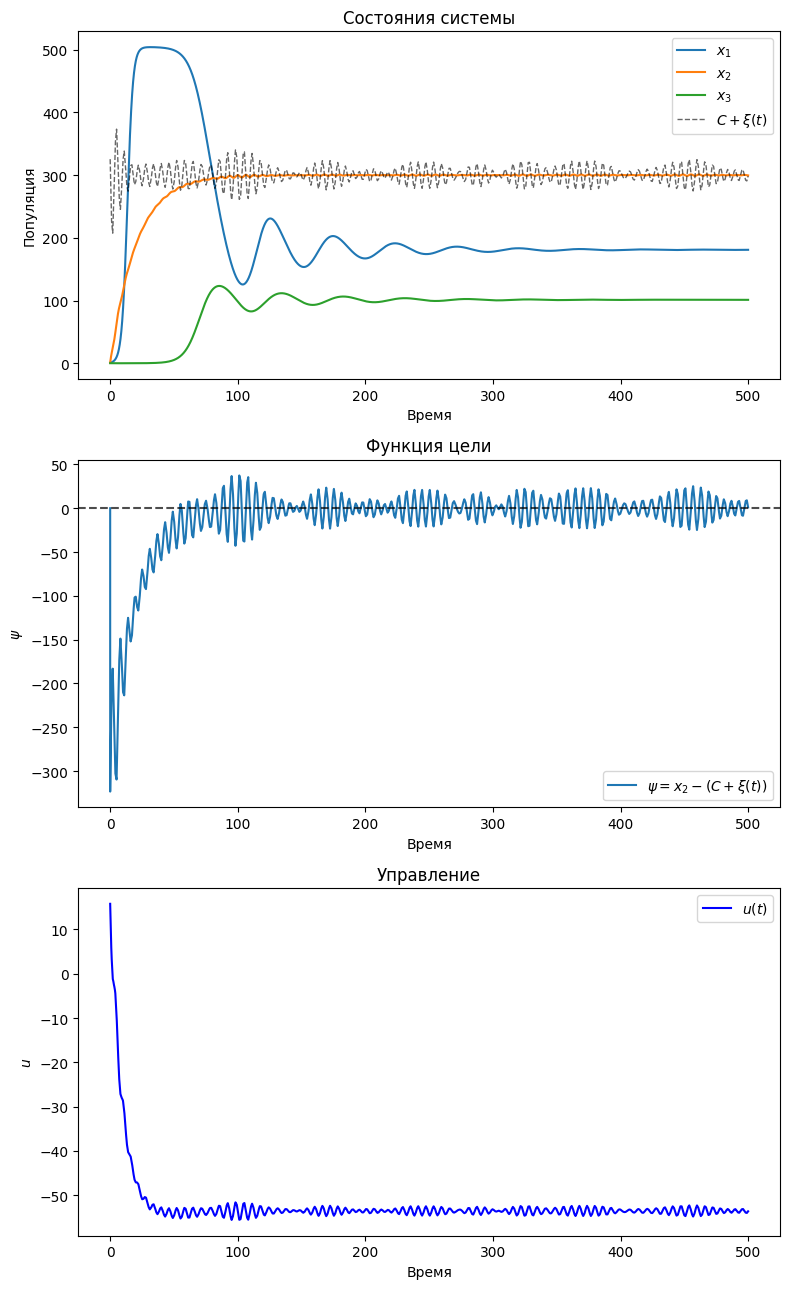

In [ ]:
from sympy import symbols, lambdify, sin
import numpy as np
import matplotlib.pyplot as plt

# возможные переменные
x1_sym, x2_sym, x3_sym, T, T1, a1, a2, b1, r1, r2, K1, K2, w1, w2, d1, d2, g1, g2, m, m1, C = symbols(
    'x1 x2 x3 T T1 a1 a2 b1 r1 r2 K1 K2 w1 w2 d1 d2 g1 g2 m m1 C')
t_sym = symbols('t')

possible_vars = [x1_sym, x2_sym, x3_sym, T, T1, a1, a2, b1, r1, r2, K1, K2,
                 w1, w2, d1, d2, g1, g2, m, m1, t_sym, C]

# Вычисляем управление с целью x2 - C
u_expr = compute_u(upr_k=2, psi_str="x2 - C")

# Фильтруем переменные, которые есть в u
used_vars = [v for v in possible_vars if v in u_expr.free_symbols]

u_func = lambdify(used_vars, u_expr, modules='numpy')

dt = 0.01
t = np.arange(0, 500, dt)

C_vals = np.zeros_like(t)

t_s_original = np.linspace(0, t[-1], len(s), endpoint=True)

s_interp = np.interp(t, t_s_original, s)

C_vals[0] = 300 + s_interp[0]

values_dict = {
    x1_sym: 1,
    x2_sym: 1,
    x3_sym: 0.1,
    T: 20,
    T1: 20,
    a1: 0.002,
    a2: 0.001,
    b1: 0.49,
    r1: 0.4632,
    r2: 0.4425,
    K1: 505,
    K2: 505,
    w1: 0.6625,
    w2: 0.435,
    d1: 45,
    d2: 30,
    g1: 0.516,
    g2: 0.45,
    m: 0.309,
    m1: 0.001,
    t_sym: 0.0,
    C: C_vals[0]
}

x1_vals = np.zeros_like(t)
x2_vals = np.zeros_like(t)
x3_vals = np.zeros_like(t)
psi = np.zeros_like(t)
u_vals = np.zeros_like(t)

x1_vals[0] = 1
x2_vals[0] = 1
x3_vals[0] = 0.1

def C_func(index):
    return 300 + s_interp[index]

for i in range(1, len(t)):
    current_time = t[i-1]
    values_dict[t_sym] = current_time

    values_dict[x1_sym] = x1_vals[i-1]
    values_dict[x2_sym] = x2_vals[i-1]
    values_dict[x3_sym] = x3_vals[i-1]

    args = [values_dict[v] for v in used_vars]
    u_vals[i-1] = u_func(*args)

    # модель
    dx1 = (
        values_dict[r1] * x1_vals[i-1] * (1 - (x1_vals[i-1] + values_dict[a1] * x2_vals[i-1]) / values_dict[K1])
        - (values_dict[w1] * x1_vals[i-1] * x3_vals[i-1]) / (values_dict[d1] + x1_vals[i-1])
    )

    dx2 = (
        values_dict[r2] * x2_vals[i-1] * (1 - (x2_vals[i-1] + values_dict[a2] * x1_vals[i-1]) / values_dict[K2])
        - (values_dict[w2] * x2_vals[i-1] * x3_vals[i-1]) / (values_dict[d2] + values_dict[b1] * x2_vals[i-1] ** 2)
        + u_vals[i-1]  # Управление подается в x2
    )

    dx3 = (
        (values_dict[g1] * x1_vals[i-1] * x3_vals[i-1]) / (values_dict[d1] + x1_vals[i-1])
        - (values_dict[g2] * x2_vals[i-1] * x3_vals[i-1]) / (values_dict[d2] + values_dict[b1] * x2_vals[i-1] ** 2)
        - values_dict[m] * x3_vals[i-1]
        - values_dict[m1] * x3_vals[i-1] ** 2
    )

    x1_vals[i] = max(0, x1_vals[i-1] + dx1 * dt)
    x2_vals[i] = max(0, x2_vals[i-1] + dx2 * dt)
    x3_vals[i] = max(0, x3_vals[i-1] + dx3 * dt)

    C_vals[i] = C_func(i)
    values_dict[C] = C_vals[i]
    psi[i] = x2_vals[i] - C_vals[i]

print("Последние значения")
print("x1:", x1_vals[-1])
print("x2:", x2_vals[-1])
print("x3:", x3_vals[-1])
print("psi:", psi[-1])

# финальное значение u
values_dict[x1_sym] = x1_vals[-1]
values_dict[x2_sym] = x2_vals[-1]
values_dict[x3_sym] = x3_vals[-1]
args = [values_dict[v] for v in used_vars]
u_vals[-1] = u_func(*args)

# графики
plt.figure(figsize=(8, 13))

# График 1: Состояния системы
plt.subplot(3, 1, 1)
plt.plot(t, x1_vals, linewidth=1.5, label=r'$x_1$')
plt.plot(t, x2_vals, linewidth=1.5, label=r'$x_2$')
plt.plot(t, x3_vals, linewidth=1.5, label=r'$x_3$')
plt.plot(t, C_vals, 'black', linestyle='--', linewidth=1, alpha=0.6, label=r'$C + \xi(t)$')
plt.title('Состояния системы')
plt.xlabel('Время')
plt.ylabel('Популяция')
plt.legend(loc='best')

# График 2: Функция цели
plt.subplot(3, 1, 2)
plt.plot(t, psi, linewidth=1.5, label=r'$\psi = x_2 - (C + \xi(t))$')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.7)
plt.title('Функция цели')
plt.xlabel('Время')
plt.ylabel(r'$\psi$')
plt.legend(loc='best')

# График 3: Управление
plt.subplot(3, 1, 3)
plt.plot(t, u_vals, 'b-', linewidth=1.5, label=r'$u(t)$')
plt.title('Управление')
plt.xlabel('Время')
plt.ylabel(r'$u$')
plt.legend(loc='best')

plt.tight_layout()
plt.show()

## цель баланс

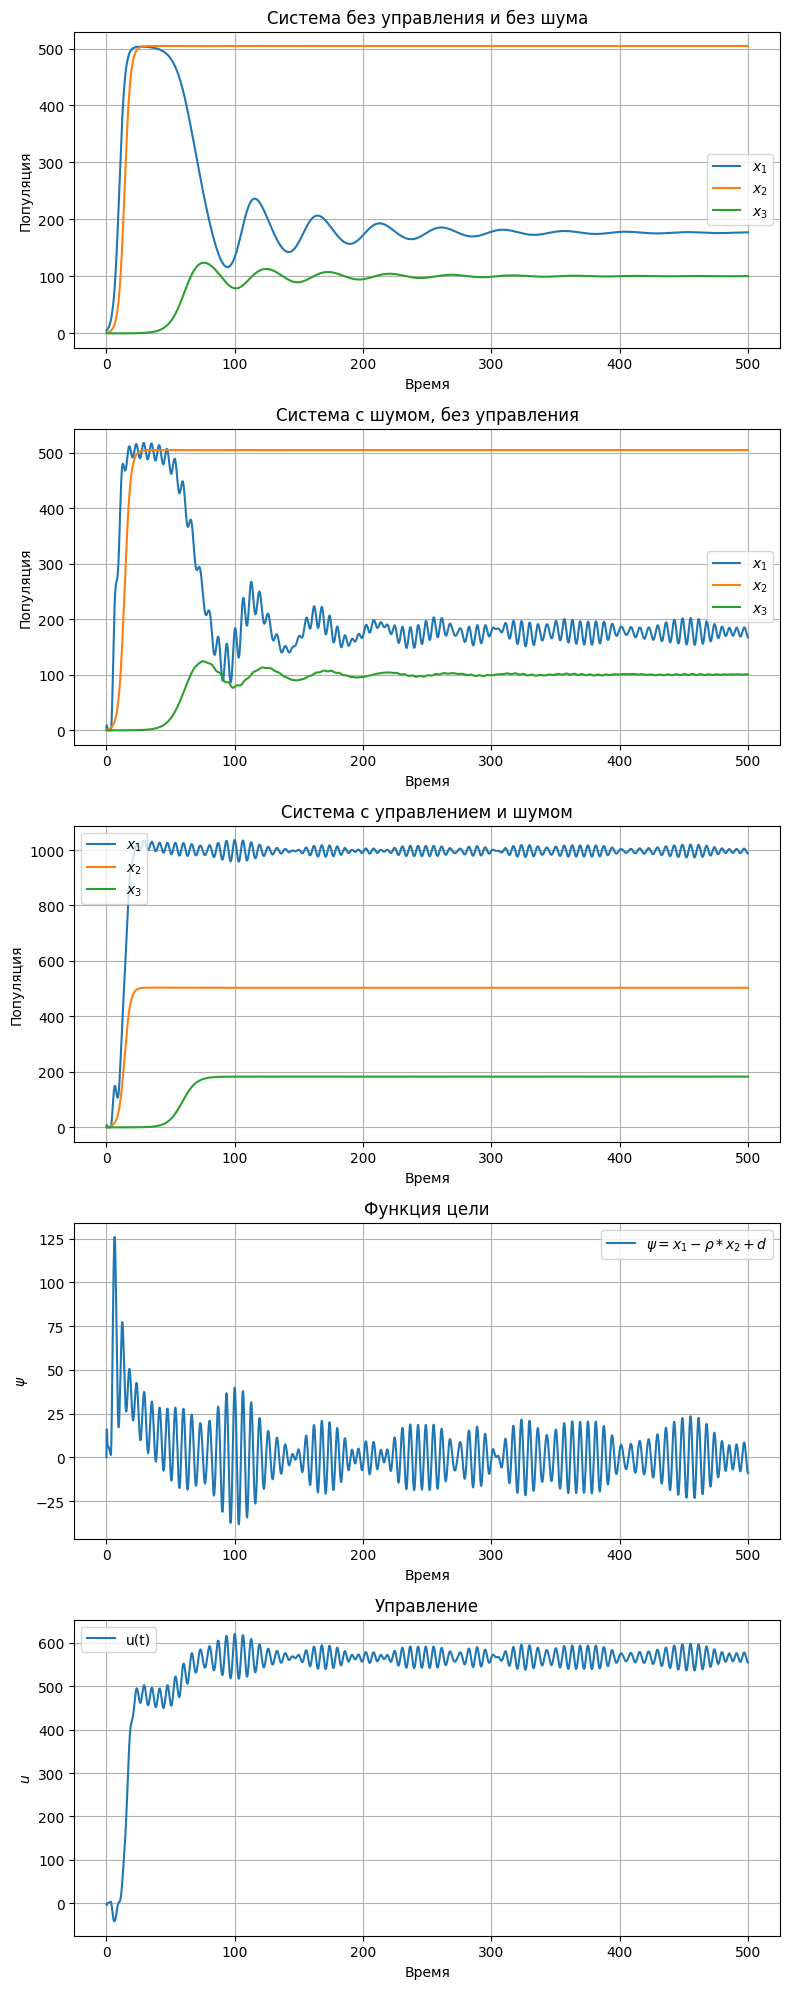

In [ ]:
from sympy import symbols, lambdify, sin, sympify
import numpy as np
import matplotlib.pyplot as plt

# Определяем символы
x1_sym, x2_sym, x3_sym, T, T1, a1, a2, b1, r1, r2, K1, K2, w1, w2, d1, d2, g1, g2, m, m1, C, t_sym, rho, d = symbols(
    'x1 x2 x3 T T1 a1 a2 b1 r1 r2 K1 K2 w1 w2 d1 d2 g1 g2 m m1 C t rho d'
)

possible_vars = [x1_sym, x2_sym, x3_sym, T, T1, a1, a2, b1, r1, r2, K1, K2,
                 w1, w2, d1, d2, g1, g2, m, m1, t_sym, C, rho, d]

# Параметры
values_dict = {
    x1_sym: 5,
    x2_sym: 1,
    x3_sym: 0.1,
    T: 20,
    T1: 20,
    a1: 0.002,
    a2: 0.001,
    b1: 0.49,
    r1: 0.4632,
    r2: 0.4425,
    K1: 505,
    K2: 505,
    w1: 0.6625,
    w2: 0.435,
    d1: 45,
    d2: 30,
    g1: 0.516,
    g2: 0.45,
    m: 0.309,
    m1: 0.001,
    t_sym: 0.0,
    C: 300,
    rho: 2,
    d: 10
}

# Время и шаг
dt = 0.01
t = np.arange(0, 500, dt)

t_s_original = np.linspace(0, t[-1], len(s), endpoint=True)

s_interp = np.interp(t, t_s_original, s)

# Массивы для хранения значений
x1_no_control_no_noise = np.zeros_like(t)
x2_no_control_no_noise = np.zeros_like(t)
x3_no_control_no_noise = np.zeros_like(t)

x1_no_control_with_noise = np.zeros_like(t)
x2_no_control_with_noise = np.zeros_like(t)
x3_no_control_with_noise = np.zeros_like(t)

x1_with_control = np.zeros_like(t)
x2_with_control = np.zeros_like(t)
x3_with_control = np.zeros_like(t)

u_vals = np.zeros_like(t)
psi_vals = np.zeros_like(t)

# Начальные условия
x1_no_control_no_noise[0] = 5
x2_no_control_no_noise[0] = 1
x3_no_control_no_noise[0] = 0.1

x1_no_control_with_noise[0] = 5
x2_no_control_with_noise[0] = 1
x3_no_control_with_noise[0] = 0.1

x1_with_control[0] = 5
x2_with_control[0] = 1
x3_with_control[0] = 0.1

# Шум
s_interp = np.interp(t, t_s_original, s)  # Интерполируем шум на сетку t

# Вычисляем управление
psi_str = "x1 - rho * x2 + d"
u_expr = compute_u(upr_k=1, psi_str=psi_str)
used_vars = [v for v in possible_vars if v in u_expr.free_symbols]
u_func = lambdify(used_vars, u_expr, modules='numpy')

# Моделирование без управления и без шума
for i in range(1, len(t)):
    current_time = t[i-1]
    values_dict[t_sym] = current_time

    values_dict[x1_sym] = x1_no_control_no_noise[i-1]
    values_dict[x2_sym] = x2_no_control_no_noise[i-1]
    values_dict[x3_sym] = x3_no_control_no_noise[i-1]

    # Модель без управления и без шума
    dx1 = (
        values_dict[r1] * x1_no_control_no_noise[i-1] * (1 - (x1_no_control_no_noise[i-1] + values_dict[a1] * x2_no_control_no_noise[i-1]) / values_dict[K1])
        - (values_dict[w1] * x1_no_control_no_noise[i-1] * x3_no_control_no_noise[i-1]) / (values_dict[d1] + x1_no_control_no_noise[i-1])
    )

    dx2 = (
        values_dict[r2] * x2_no_control_no_noise[i-1] * (1 - (x2_no_control_no_noise[i-1] + values_dict[a2] * x1_no_control_no_noise[i-1]) / values_dict[K2])
        - (values_dict[w2] * x2_no_control_no_noise[i-1] * x3_no_control_no_noise[i-1]) / (values_dict[d2] + values_dict[b1] * x2_no_control_no_noise[i-1] ** 2)
    )

    dx3 = (
        (values_dict[g1] * x1_no_control_no_noise[i-1] * x3_no_control_no_noise[i-1]) / (values_dict[d1] + x1_no_control_no_noise[i-1])
        - (values_dict[g2] * x2_no_control_no_noise[i-1] * x3_no_control_no_noise[i-1]) / (values_dict[d2] + values_dict[b1] * x2_no_control_no_noise[i-1] ** 2)
        - values_dict[m] * x3_no_control_no_noise[i-1]
        - values_dict[m1] * x3_no_control_no_noise[i-1] ** 2
    )

    x1_no_control_no_noise[i] = max(0, x1_no_control_no_noise[i-1] + dx1 * dt)
    x2_no_control_no_noise[i] = max(0, x2_no_control_no_noise[i-1] + dx2 * dt)
    x3_no_control_no_noise[i] = max(0, x3_no_control_no_noise[i-1] + dx3 * dt)

# Моделирование с шумом, без управления
for i in range(1, len(t)):
    current_time = t[i-1]
    values_dict[t_sym] = current_time

    values_dict[x1_sym] = x1_no_control_with_noise[i-1]
    values_dict[x2_sym] = x2_no_control_with_noise[i-1]
    values_dict[x3_sym] = x3_no_control_with_noise[i-1]

    # Модель с шумом, без управления
    dx1 = (
        values_dict[r1] * x1_no_control_with_noise[i-1] * (1 - (x1_no_control_with_noise[i-1] + values_dict[a1] * x2_no_control_with_noise[i-1]) / values_dict[K1])
        - (values_dict[w1] * x1_no_control_with_noise[i-1] * x3_no_control_with_noise[i-1]) / (values_dict[d1] + x1_no_control_with_noise[i-1])
        + s_interp[i]  # Добавление шума
    )

    dx2 = (
        values_dict[r2] * x2_no_control_with_noise[i-1] * (1 - (x2_no_control_with_noise[i-1] + values_dict[a2] * x1_no_control_with_noise[i-1]) / values_dict[K2])
        - (values_dict[w2] * x2_no_control_with_noise[i-1] * x3_no_control_with_noise[i-1]) / (values_dict[d2] + values_dict[b1] * x2_no_control_with_noise[i-1] ** 2)

    )

    dx3 = (
        (values_dict[g1] * x1_no_control_with_noise[i-1] * x3_no_control_with_noise[i-1]) / (values_dict[d1] + x1_no_control_with_noise[i-1])
        - (values_dict[g2] * x2_no_control_with_noise[i-1] * x3_no_control_with_noise[i-1]) / (values_dict[d2] + values_dict[b1] * x2_no_control_with_noise[i-1] ** 2)
        - values_dict[m] * x3_no_control_with_noise[i-1]
        - values_dict[m1] * x3_no_control_with_noise[i-1] ** 2
    )

    x1_no_control_with_noise[i] = max(0, x1_no_control_with_noise[i-1] + dx1 * dt)
    x2_no_control_with_noise[i] = max(0, x2_no_control_with_noise[i-1] + dx2 * dt)
    x3_no_control_with_noise[i] = max(0, x3_no_control_with_noise[i-1] + dx3 * dt)

# Моделирование с управлением и шумом
for i in range(1, len(t)):
    current_time = t[i-1]
    values_dict[t_sym] = current_time

    values_dict[x1_sym] = x1_with_control[i-1]
    values_dict[x2_sym] = x2_with_control[i-1]
    values_dict[x3_sym] = x3_with_control[i-1]

    # Вычисляем управление
    args = [values_dict[v] for v in used_vars]
    u_vals[i-1] = u_func(*args)

    # Модель с управлением и шумом
    dx1 = (
        values_dict[r1] * x1_with_control[i-1] * (1 - (x1_with_control[i-1] + values_dict[a1] * x2_with_control[i-1]) / values_dict[K1])
        - (values_dict[w1] * x1_with_control[i-1] * x3_with_control[i-1]) / (values_dict[d1] + x1_with_control[i-1])
        + u_vals[i-1]
        + s_interp[i]  # Добавление шума
    )

    dx2 = (
        values_dict[r2] * x2_with_control[i-1] * (1 - (x2_with_control[i-1] + values_dict[a2] * x1_with_control[i-1]) / values_dict[K2])
        - (values_dict[w2] * x2_with_control[i-1] * x3_with_control[i-1]) / (values_dict[d2] + values_dict[b1] * x2_with_control[i-1] ** 2)

    )

    dx3 = (
        (values_dict[g1] * x1_with_control[i-1] * x3_with_control[i-1]) / (values_dict[d1] + x1_with_control[i-1])
        - (values_dict[g2] * x2_with_control[i-1] * x3_with_control[i-1]) / (values_dict[d2] + values_dict[b1] * x2_with_control[i-1] ** 2)
        - values_dict[m] * x3_with_control[i-1]
        - values_dict[m1] * x3_with_control[i-1] ** 2
    )

    x1_with_control[i] = max(0, x1_with_control[i-1] + dx1 * dt)
    x2_with_control[i] = max(0, x2_with_control[i-1] + dx2 * dt)
    x3_with_control[i] = max(0, x3_with_control[i-1] + dx3 * dt)

    psi_vals[i] = x1_with_control[i] - values_dict[rho] * x2_with_control[i] + values_dict[d]

# Последние значения
values_dict[x1_sym] = x1_with_control[-1]
values_dict[x2_sym] = x2_with_control[-1]
values_dict[x3_sym] = x3_with_control[-1]
args = [values_dict[v] for v in used_vars]
u_vals[-1] = u_func(*args)

# Графики
plt.figure(figsize=(8, 20))

# 1. Без управления и без шума
plt.subplot(5, 1, 1)
plt.plot(t, x1_no_control_no_noise, label=r'$x_1$')
plt.plot(t, x2_no_control_no_noise, label=r'$x_2$')
plt.plot(t, x3_no_control_no_noise, label=r'$x_3$')
plt.title('Система без управления и без шума')
plt.xlabel('Время')
plt.ylabel('Популяция')
plt.legend()
plt.grid()

# 2. С шумом, но без управления
plt.subplot(5, 1, 2)
plt.plot(t, x1_no_control_with_noise, label=r'$x_1$')
plt.plot(t, x2_no_control_with_noise, label=r'$x_2$')
plt.plot(t, x3_no_control_with_noise, label=r'$x_3$')
plt.title('Система с шумом, без управления')
plt.xlabel('Время')
plt.ylabel('Популяция')
plt.legend()
plt.grid()

# 3. С управлением и шумом
plt.subplot(5, 1, 3)
plt.plot(t, x1_with_control, label=r'$x_1$')
plt.plot(t, x2_with_control, label=r'$x_2$')
plt.plot(t, x3_with_control, label=r'$x_3$')
plt.title('Система с управлением и шумом')
plt.xlabel('Время')
plt.ylabel('Популяция')
plt.legend()
plt.grid()

# 4. График функции цели
plt.subplot(5, 1, 4)
plt.plot(t, psi_vals, label=r'$\psi = x_1 - \rho * x_2 + d$')
plt.title('Функция цели')
plt.xlabel('Время')
plt.ylabel(r'$\psi$')
plt.legend()
plt.grid()

# 5. Управление
plt.subplot(5, 1, 5)
plt.plot(t, u_vals, label='u(t)')
plt.xlabel('Время')
plt.ylabel(r'$u$')
plt.title('Управление')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


# Вспомогательные выводы

In [ ]:
latex_output_u = sympy.latex(u_final, mode='inline')
print(latex_output_u)

latex_output_phi = sympy.latex(phi_expr, mode='inline')
print(latex_output_phi)

latex_output_dphi = sympy.latex(d_phi_expr, mode='inline')
print(latex_output_dphi)

$- \frac{K_{1} K_{2} \left(d_{1} + x_{1}\right) \left(b_{1} x_{2}^{2} + d_{2}\right)^{2} \left(C K_{2} b_{1} x_{2}^{2} + C K_{2} d_{2} - K_{2} T b_{1} r_{2} x_{2}^{3} - K_{2} T d_{2} r_{2} x_{2} + K_{2} T w_{2} x_{2} x_{3} - K_{2} b_{1} x_{2}^{3} - K_{2} d_{2} x_{2} + T b_{1} r_{2} x_{2}^{4} + T d_{2} r_{2} x_{2}^{2}\right) - K_{1} T_{1} \left(K_{2}^{2} T w_{2} x_{2} x_{3} \left(b_{1} x_{2}^{2} + d_{2}\right) \left(- g_{1} x_{1} \left(b_{1} x_{2}^{2} + d_{2}\right) + g_{2} x_{2} \left(d_{1} + x_{1}\right) + \left(d_{1} + x_{1}\right) \left(m + m_{1} x_{3}\right) \left(b_{1} x_{2}^{2} + d_{2}\right)\right) - \left(d_{1} + x_{1}\right) \left(K_{2} w_{2} x_{3} - r_{2} \left(b_{1} x_{2}^{2} + d_{2}\right) \left(K_{2} - a_{2} x_{1} - x_{2}\right)\right) \left(2 b_{1} x_{2}^{2} \left(C K_{2} b_{1} x_{2}^{2} + C K_{2} d_{2} - K_{2} T b_{1} r_{2} x_{2}^{3} - K_{2} T d_{2} r_{2} x_{2} + K_{2} T w_{2} x_{2} x_{3} - K_{2} b_{1} x_{2}^{3} - K_{2} d_{2} x_{2} + T b_{1} r_{2} x_{2}^{4} + T d_{2} r_{

In [ ]:
latex_output_u = sympy.latex(u_final, mode='inline')
print(latex_output_u)

latex_output_phi = sympy.latex(phi_expr, mode='inline')
print(latex_output_phi)

latex_output_dphi = sympy.latex(d_phi_expr, mode='inline')
print(latex_output_dphi)

$\frac{K_{1}^{2} K_{2}^{2} T x_{3} \left(d_{1} + x_{1}\right) \left(b_{1} x_{2}^{2} + d_{2}\right) \left(b_{1} w_{1} x_{1} x_{2}^{2} - d_{1} ro w_{2} x_{2} + d_{2} w_{1} x_{1} - ro w_{2} x_{1} x_{2}\right)^{2} \left(T_{1} b_{1} d_{1} m x_{2}^{2} + T_{1} b_{1} d_{1} m_{1} x_{2}^{2} x_{3} - T_{1} b_{1} g_{1} x_{1} x_{2}^{2} + T_{1} b_{1} m x_{1} x_{2}^{2} + T_{1} b_{1} m_{1} x_{1} x_{2}^{2} x_{3} + T_{1} d_{1} d_{2} m + T_{1} d_{1} d_{2} m_{1} x_{3} + T_{1} d_{1} g_{2} x_{2} - T_{1} d_{2} g_{1} x_{1} + T_{1} d_{2} m x_{1} + T_{1} d_{2} m_{1} x_{1} x_{3} + T_{1} g_{2} x_{1} x_{2} - b_{1} d_{1} x_{2}^{2} - b_{1} x_{1} x_{2}^{2} - d_{1} d_{2} - d_{2} x_{1}\right) + K_{1} K_{2} \left(d_{1} + x_{1}\right) \left(b_{1} x_{2}^{2} + d_{2}\right) \left(b_{1} d_{1} x_{2}^{2} + b_{1} x_{1} x_{2}^{2} + d_{1} d_{2} + d_{2} x_{1}\right) \left(b_{1} w_{1} x_{1} x_{2}^{2} - d_{1} ro w_{2} x_{2} + d_{2} w_{1} x_{1} - ro w_{2} x_{1} x_{2}\right) \left(K_{1} K_{2} T b_{1} d_{1} r_{1} x_{1} x_{2}^{2} - K_{1}

[x1, x2, x3]
24.95 24.95
24.94913675308319 24.94913675308319
24.935363613424588 24.935363613424588
24.9280550795272 24.9280550795272
24.891523041958827 24.891523041958827
24.885033974428914 24.885033974428914
24.876925153192012 24.876925153192012
24.8769252888242 24.8769252888242
24.7309901003132 24.7309901003132
24.658985616002894 24.658985616002894
24.299932874309597 24.299932874309597
24.23655980876232 24.23655980876232
24.15770993174813 24.15770993174813
24.157846703227047 24.157846703227047
23.730059030377255 23.730059030377255
23.524687376504545 23.524687376504545
22.50461533676279 22.50461533676279
22.32546508304332 22.32546508304332
22.107119717473303 22.107119717473303
22.11086539179672 22.11086539179672
21.509142433330076 21.509142433330076
21.226703088480512 21.226703088480512
19.82606272352945 19.82606272352945
19.578479950713014 19.578479950713014
19.28527308920161 19.28527308920161
19.297964398940074 19.297964398940074
18.661317692082665 18.661317692082672
18.366622940023

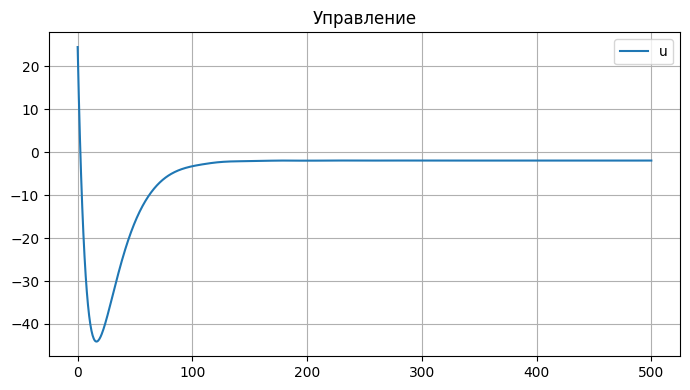

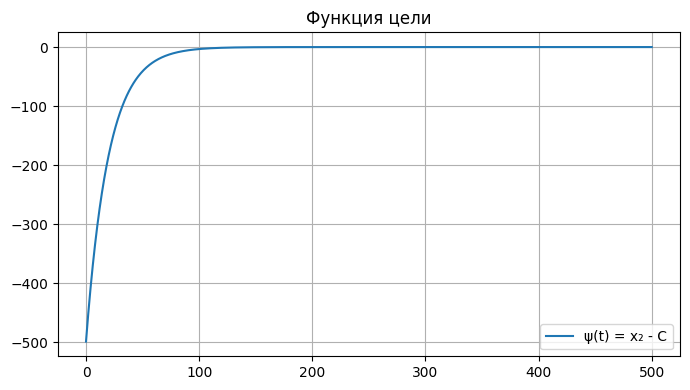

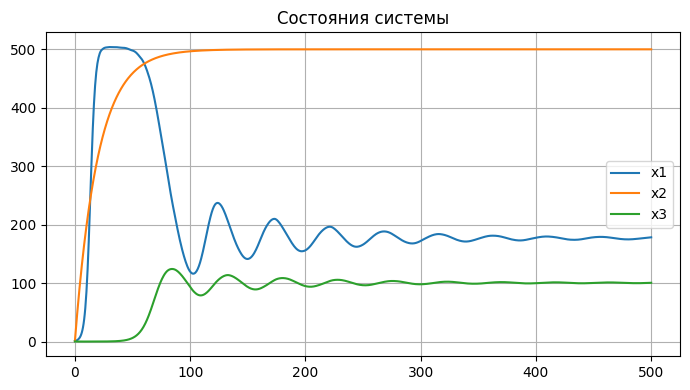

In [ ]:
import numpy as np
import sympy as sp
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# u=u[0]

# 3. Система уравнений
dx1 = r1 * x1 * (1 - (x1 + a1 * x2) / K1) - (w1 * x1 * x3) / (d1 + x1)
dx2 = r2 * x2 * (1 - (x2 + a2 * x1) / K2) - (w2 * x2 * x3) / (d2 + b1 * x2**2) + u
dx3 = (g1 * x1 * x3) / (d1 + x1) - (g2 * x2 * x3) / (d2 + b1 * x2**2) - m * x3 - m1 * x3**2

# 4. Сборка системы
system = sp.Matrix([dx1, dx2, dx3])
vars_ = [x1, x2, x3]

# 5. Параметры
params = {
    T: 20,
    T1: 20,
    a1: 0.002,
    a2: 0.001,
    b1: 0.49,
    C: 500,
    r1: 0.4632,
    r2: 0.4425,
    K1: 505,
    K2: 505,
    w1: 0.6625,
    w2: 0.435,
    d1: 45,
    d2: 30,
    g1: 0.516,
    g2: 0.45,
    m: 0.309,
    m1: 0.001
}

# 6. Объединяем u с системой и подставляем параметры
system_subs = system.subs(params)
u_subs = u.subs(params)

# 7. lambdify переменные из u
possible_vars = [x1, x2, x3, T, T1, a1, a2, b1, C, r1, r2, K1, K2, w1, w2, d1, d2, g1, g2, m, m1, t]
used_vars = [v for v in possible_vars if v in u_subs.free_symbols]
print(used_vars)
u_func = sp.lambdify(used_vars, u_subs, modules='numpy')

# 8. lambdify правую часть системы
f_func = sp.lambdify((t, [x1, x2, x3]), system_subs, modules='numpy')

# 9. Правая часть для численного интегратора
def rhs(t_val, y):
    # Словарь всех переменных с их значениями
    value_dict = {
        x1: y[0],
        x2: y[1],
        x3: y[2],
        t: t_val
    }

    # Соберем значения ТОЛЬКО для используемых переменных
    arg_vals = [value_dict[v] for v in used_vars]

    # Вычисляем u
    u_val = float(u_func(*arg_vals))

    # Основная часть системы — уже lambdified
    dxs = np.asarray(f_func(t_val, y)).flatten()

# ???
    # Обновляем dx2 вручную с учётом u
    dx2_val = (
        params[r2] * y[1] * (1 - (y[1] + params[a2] * y[0]) / params[K2]) -
        (params[w2] * y[1] * y[2]) / (params[d2] + params[b1] * y[1]**2) +
        u_val
    )
    dxs[1] = dx2_val
    return dxs

# 10. Решение ОДУ
y0 = [1.0, 1.0, 0.1]
t_span = (0, 500)
t_eval = np.linspace(*t_span, 1000)
sol = solve_ivp(rhs, t_span, y0, t_eval=t_eval)

# Значения переменных
x1_vals = sol.y[0]
x2_vals = sol.y[1]
x3_vals = sol.y[2]
t_vals = sol.t

# Восстановим значения u(y(t))
u_vals = []
for i in range(len(t_vals)):
    val_dict = {
        x1: x1_vals[i],
        x2: x2_vals[i],
        x3: x3_vals[i],
        t: t_vals[i]
    }
    args = [val_dict[v] for v in used_vars]
    u_val = float(u_func(*args))
    u_vals.append(u_val)

# Вычислим ψ(t) = x2 - C
psi_vals = x2_vals - float(params[C])  # C = 0.0 по умолчанию, можно изменить

# ==== Построение графиков ====

# График u
plt.figure(figsize=(7, 4))
plt.plot(t_vals, u_vals, label='u')
plt.title('Управление')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# График ψ(t)
plt.figure(figsize=(7, 4))
plt.plot(t_vals, psi_vals, label='ψ(t) = x₂ - C')
plt.title('Функция цели')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# 11. Графики
plt.figure(figsize=(7, 4))
plt.plot(sol.t, sol.y[0], label='x1')
plt.plot(sol.t, sol.y[1], label='x2')
plt.plot(sol.t, sol.y[2], label='x3')
plt.title('Состояния системы')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



# ГРАФИКИ


## управение x1, цель x1

Последние значения
x1:  299.9999999958714
x2:  504.1505476033447
x3:  137.87447755280223
psi:  -4.128594355279347e-09


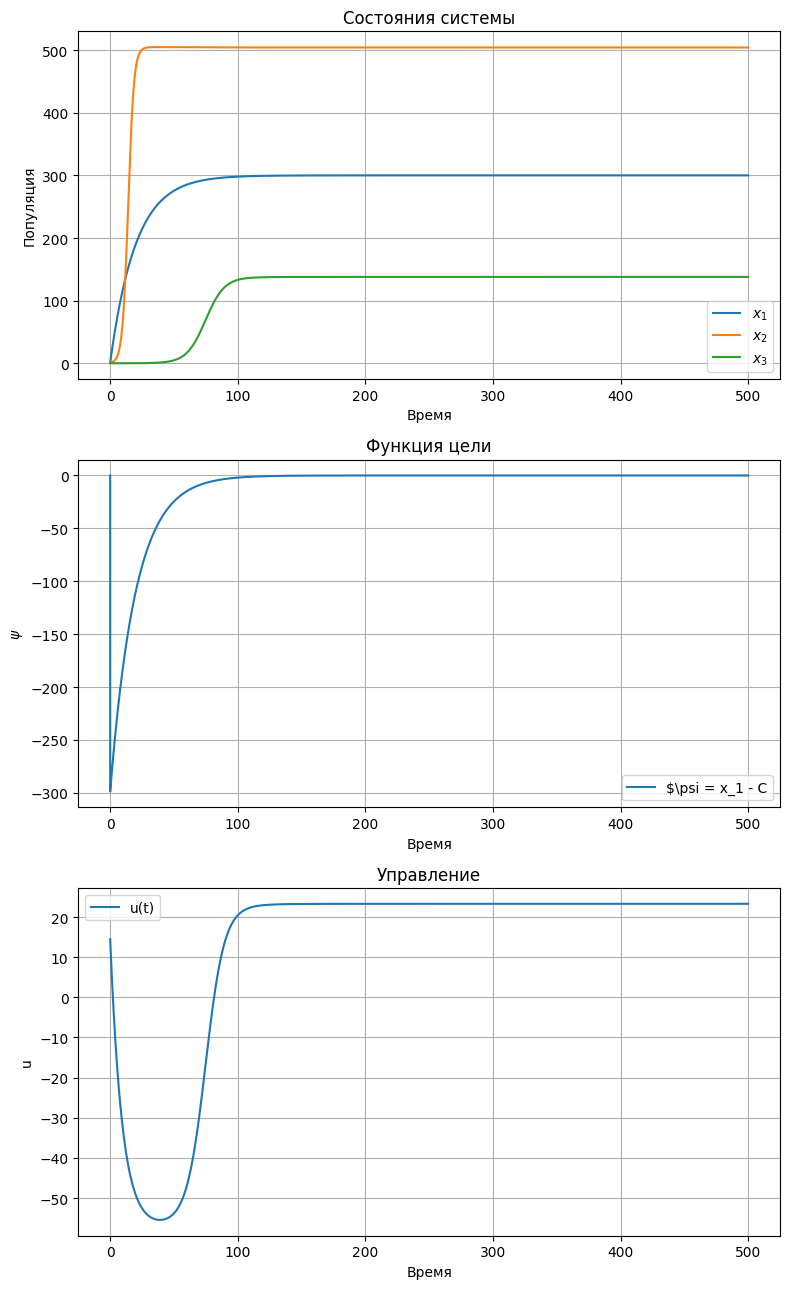

In [ ]:
from sympy import symbols, lambdify
import numpy as np
import matplotlib.pyplot as plt

# возможные переменные
x1_sym, x2_sym, x3_sym, T, T1, a1, a2, b1, C, r1, r2, K1, K2, w1, w2, d1, d2, g1, g2, m, m1, rho, d = symbols('x1 x2 x3 T T1 a1 a2 b1 C r1 r2 K1 K2 w1 w2 d1 d2 g1 g2 m m1 rho d')

possible_vars = [x1_sym, x2_sym, x3_sym, T, T1, a1, a2, b1, C, r1, r2, K1, K2, w1, w2, d1, d2, g1, g2, m, m1, rho, d]

u_expr = compute_u(upr_k=1, psi_str="x1 - C")

# Фильтруем переменные, которые есть в u
used_vars = [v for v in possible_vars if v in u_expr.free_symbols]

u_func = lambdify(used_vars, u_expr, modules='numpy')

# список значений этих переменных в нужном порядке
# численные значения параметров
values_dict = {
    x1_sym: 1,
    x2_sym: 1,
    x3_sym: 0.1,
    T: 20,
    T1: 20,
    a1: 0.002,
    a2: 0.001,
    b1: 0.49,
    C: 300,
    r1: 0.4632,
    r2: 0.4425,
    K1: 505,
    K2: 505,
    w1: 0.6625,
    w2: 0.435,
    d1: 45,
    d2: 30,
    g1: 0.516,
    g2: 0.45,
    m: 0.309,
    m1: 0.001,
    rho: 0.5,
    d: 10
}

dt = 0.01
t = np.arange(0, 500, dt)
x1_vals = np.zeros_like(t)
x2_vals = np.zeros_like(t)
x3_vals = np.zeros_like(t)
psi = np.zeros_like(t)
u_vals = np.zeros_like(t)

x1_vals[0] = 1
x2_vals[0] = 1
x3_vals[0] = 0.1

for i in range(1, len(t)):
    # обновим значения переменных в словаре
    values_dict[x1_sym] = x1_vals[i-1]
    values_dict[x2_sym] = x2_vals[i-1]
    values_dict[x3_sym] = x3_vals[i-1]

    # аргументы, в нужном порядке
    args = [values_dict[v] for v in used_vars]

    # вычисляем u
    u_vals[i-1] = u_func(*args)

    # модель
    dx1 = (
        values_dict[r1] * x1_vals[i-1] * (1 - (x1_vals[i-1] + values_dict[a1] * x2_vals[i-1]) / values_dict[K1])
        - (values_dict[w1] * x1_vals[i-1] * x3_vals[i-1]) / (values_dict[d1] + x1_vals[i-1])
        + u_vals[i-1]

    )

    dx2 = (
        values_dict[r2] * x2_vals[i-1] * (1 - (x2_vals[i-1] + values_dict[a2] * x1_vals[i-1]) / values_dict[K2])
        - (values_dict[w2] * x2_vals[i-1] * x3_vals[i-1]) / (values_dict[d2] + values_dict[b1] * x2_vals[i-1] ** 2)

    )

    dx3 = (
        (values_dict[g1] * x1_vals[i-1] * x3_vals[i-1]) / (values_dict[d1] + x1_vals[i-1])
        - (values_dict[g2] * x2_vals[i-1] * x3_vals[i-1]) / (values_dict[d2] + values_dict[b1] * x2_vals[i-1] ** 2)
        - values_dict[m] * x3_vals[i-1]
        - values_dict[m1] * x3_vals[i-1] ** 2
    )


    # x1_vals[i] = max(0, x1_vals[i-1] + dx1 * dt)
    # x2_vals[i] = max(0, x2_vals[i-1] + dx2 * dt)
    # x3_vals[i] = max(0, x3_vals[i-1] + dx3 * dt)

    x1_vals[i] = x1_vals[i-1] + dx1 * dt
    x2_vals[i] = x2_vals[i-1] + dx2 * dt
    x3_vals[i] = x3_vals[i-1] + dx3 * dt

    psi[i] = x1_vals[i] - values_dict[C]

print("Последние значения")
print("x1: ", x1_vals[-1])
print("x2: ", x2_vals[-1])
print("x3: ", x3_vals[-1])
print("psi: ", psi[-1])

# финальное значение u
values_dict[x1_sym] = x1_vals[-1]
values_dict[x2_sym] = x2_vals[-1]
values_dict[x3_sym] = x3_vals[-1]
args = [values_dict[v] for v in used_vars]
u_vals[-1] = u_func(*args)

# графики
plt.figure(figsize=(8, 13))

plt.subplot(3, 1, 1)
plt.plot(t, x1_vals, label=r'$x_1$')
plt.plot(t, x2_vals, label=r'$x_2$')
plt.plot(t, x3_vals, label=r'$x_3$')
#plt.ylim(-5, 550)
plt.title('Состояния системы')
plt.xlabel('Время')
plt.ylabel('Популяция')
plt.legend()
plt.grid()

plt.subplot(3, 1, 2)
plt.plot(t, psi, label=r'$\psi = x_1 - C')
plt.title('Функция цели')
plt.xlabel('Время')
plt.ylabel(r'$\psi$')
plt.legend()
plt.grid()

plt.subplot(3, 1, 3)
plt.plot(t, u_vals, label='u(t)')
plt.title('Управление')
plt.xlabel('Время')
plt.ylabel('u')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

## управление по x1, цель x2 - C, отрицательный ужас

In [18]:
from sympy import symbols, lambdify
import numpy as np
import matplotlib.pyplot as plt

# возможные переменные
x1_sym, x2_sym, x3_sym, T, T1, a1, a2, b1, C, r1, r2, K1, K2, w1, w2, d1, d2, g1, g2, m, m1, ro, d = symbols('x1 x2 x3 T T1 a1 a2 b1 C r1 r2 K1 K2 w1 w2 d1 d2 g1 g2 m m1 ro d')

possible_vars = [x1_sym, x2_sym, x3_sym, T, T1, a1, a2, b1, C, r1, r2, K1, K2, w1, w2, d1, d2, g1, g2, m, m1, ro, d]

u_expr = compute_u(upr_k=1, psi_str="x2 - C")

# Фильтруем переменные, которые есть в u
used_vars = [v for v in possible_vars if v in u_expr.free_symbols]

u_func = lambdify(used_vars, u_expr, modules='numpy')

# список значений этих переменных в нужном порядке
# численные значения параметров
values_dict = {
    x1_sym: 800,
    x2_sym: 450,
    x3_sym: 25,
    T: 20,
    T1: 20,
    a1: 0.002,
    a2: 0.001,
    b1: 0.49,
    C: 500,
    r1: 0.4632,
    r2: 0.4425,
    K1: 505,
    K2: 505,
    w1: 0.6625,
    w2: 0.435,
    d1: 45,
    d2: 30,
    g1: 0.516,
    g2: 0.45,
    m: 0.309,
    m1: 0.001,
    ro: 0.5,
    d: 10
}

dt = 0.01
t = np.arange(0, 500, dt)
x1_vals = np.zeros_like(t)
x2_vals = np.zeros_like(t)
x3_vals = np.zeros_like(t)
psi = np.zeros_like(t)
u_vals = np.zeros_like(t)

x1_vals[0] = 800
x2_vals[0] = 450
x3_vals[0] = 25

for i in range(1, len(t)):
    # обновим значения переменных в словаре
    values_dict[x1_sym] = x1_vals[i-1]
    values_dict[x2_sym] = x2_vals[i-1]
    values_dict[x3_sym] = x3_vals[i-1]

    # аргументы, в нужном порядке
    args = [values_dict[v] for v in used_vars]

    # вычисляем u
    u_vals[i-1] = u_func(*args)

    # модель
    dx1 = (
        values_dict[r1] * x1_vals[i-1] * (1 - (x1_vals[i-1] + values_dict[a1] * x2_vals[i-1]) / values_dict[K1])
        - (values_dict[w1] * x1_vals[i-1] * x3_vals[i-1]) / (values_dict[d1] + x1_vals[i-1])
        + u_vals[i-1]

    )

    dx2 = (
        values_dict[r2] * x2_vals[i-1] * (1 - (x2_vals[i-1] + values_dict[a2] * x1_vals[i-1]) / values_dict[K2])
        - (values_dict[w2] * x2_vals[i-1] * x3_vals[i-1]) / (values_dict[d2] + values_dict[b1] * x2_vals[i-1] ** 2)

    )

    dx3 = (
        (values_dict[g1] * x1_vals[i-1] * x3_vals[i-1]) / (values_dict[d1] + x1_vals[i-1])
        - (values_dict[g2] * x2_vals[i-1] * x3_vals[i-1]) / (values_dict[d2] + values_dict[b1] * x2_vals[i-1] ** 2)
        - values_dict[m] * x3_vals[i-1]
        - values_dict[m1] * x3_vals[i-1] ** 2
    )


    # x1_vals[i] = max(0, x1_vals[i-1] + dx1 * dt)
    # x2_vals[i] = max(0, x2_vals[i-1] + dx2 * dt)
    # x3_vals[i] = max(0, x3_vals[i-1] + dx3 * dt)

    x1_vals[i] = x1_vals[i-1] + dx1 * dt
    x2_vals[i] = x2_vals[i-1] + dx2 * dt
    x3_vals[i] = x3_vals[i-1] + dx3 * dt

    psi[i] = x2_vals[i] - values_dict[C]

print("Последние значения")
print("x1: ", x1_vals[-1])
print("x2: ", x2_vals[-1])
print("x3: ", x3_vals[-1])
print("psi: ", psi[-1])

# финальное значение u
values_dict[x1_sym] = x1_vals[-1]
values_dict[x2_sym] = x2_vals[-1]
values_dict[x3_sym] = x3_vals[-1]
args = [values_dict[v] for v in used_vars]
u_vals[-1] = u_func(*args)

# графики
plt.figure(figsize=(8, 13))

plt.subplot(3, 1, 1)
plt.plot(t, x1_vals, label='x1')
plt.plot(t, x2_vals, label='x2')
plt.plot(t, x3_vals, label='x3')
#plt.ylim(-5, 550)
plt.title('Состояния системы')
plt.legend()
plt.grid()

plt.subplot(3, 1, 2)
plt.plot(t, psi, label='ψ = x2 - C')
plt.title('Функция цели')
plt.legend()
plt.grid()

plt.subplot(3, 1, 3)
plt.plot(t, u_vals, label='u(t)')
plt.title('Управление')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

AttributeError: module 'sympy' has no attribute 'external'

## ввод ограничений на управление

РЕЗУЛЬТАТЫ МОДЕЛИРОВАНИЯ
x1 начальное: 200.00
x2 начальное: 450.00
x3 начальное: 25.00
Цель C: 500.00
Минимальный порог x1: 5.00
--------------------------------------------------
x1 конечное: 1263.44
x2 конечное: 502.99
x3 конечное: 187.43
psi конечное: 2.99
u конечное: 1000.00
Макс. u: 1000.00
Мин. u: -16145.42
Минимальное x1 в процессе: 5.00


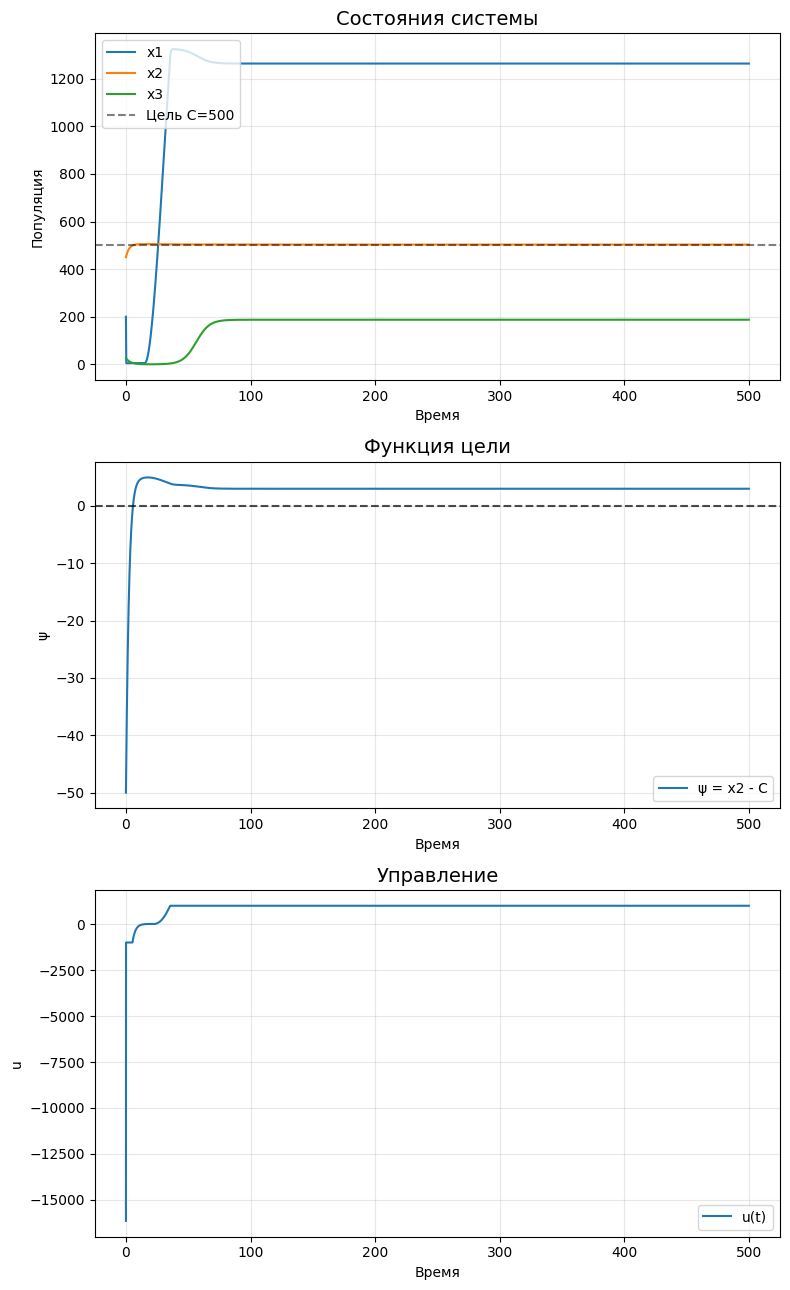

In [ ]:
from sympy import symbols, lambdify
import numpy as np
import matplotlib.pyplot as plt

# возможные переменные
x1_sym, x2_sym, x3_sym, T, T1, a1, a2, b1, C, r1, r2, K1, K2, w1, w2, d1, d2, g1, g2, m, m1 = symbols('x1 x2 x3 T T1 a1 a2 b1 C r1 r2 K1 K2 w1 w2 d1 d2 g1 g2 m m1')

possible_vars = [x1_sym, x2_sym, x3_sym, T, T1, a1, a2, b1, C, r1, r2, K1, K2, w1, w2, d1, d2, g1, g2, m, m1]

# фильтрация переменных, которые есть в u
used_vars = [v for v in possible_vars if v in u_final.free_symbols]

# создаём численную функцию u(t)
u_func = lambdify(used_vars, u_final, modules='numpy')

# численные значения параметров
values_dict = {
    x1_sym: 200,
    x2_sym: 450,
    x3_sym: 25,
    T: 20,
    T1: 20,
    a1: 0.002,
    a2: 0.001,
    b1: 0.49,
    C: 500,           # цель для x2
    r1: 0.4632,
    r2: 0.4425,
    K1: 505,
    K2: 505,
    w1: 0.6625,
    w2: 0.435,
    d1: 45,
    d2: 30,
    g1: 0.516,
    g2: 0.45,
    m: 0.309,
    m1: 0.001
}

# ПАРАМЕТРЫ МОДЕЛИРОВАНИЯ
dt = 0.01
t = np.arange(0, 500, dt)

# ИНИЦИАЛИЗАЦИЯ МАССИВОВ
x1_vals = np.zeros_like(t)
x2_vals = np.zeros_like(t)
x3_vals = np.zeros_like(t)
u_vals = np.zeros_like(t)
psi_vals = np.zeros_like(t)

# НАЧАЛЬНЫЕ УСЛОВИЯ
x1_vals[0] = 200
x2_vals[0] = 450
x3_vals[0] = 25
psi_vals[0] = x2_vals[0] - values_dict[C]

# БИОЛОГИЧЕСКОЕ ОГРАНИЧЕНИЕ
x1_min = 5.0  # критический минимум: ниже этого фитопланктон вымирает
# форма ограничения: u_used = u_raw * (x1 / (x1 + x1_min))
# при x1 = x1_min управление ослабляется в 2 раза
# при x1 -> 0 управление -> 0

# вычисляем начальное u
args = [values_dict[v] for v in used_vars]
u_vals[0] = u_func(*args)

for i in range(1, len(t)):
    # ТЕКУЩИЕ ЗНАЧЕНИЯ
    x1 = x1_vals[i-1]
    x2 = x2_vals[i-1]
    x3 = x3_vals[i-1]

    # ОБНОВЛЕНИЕ СЛОВАРЯ
    values_dict[x1_sym] = x1
    values_dict[x2_sym] = x2
    values_dict[x3_sym] = x3

    # РАСЧЕТ УПРАВЛЕНИЯ С ОГРАНИЧЕНИЕМ
    args = [values_dict[v] for v in used_vars]
    u_raw = u_func(*args)

    # ПЛАВНОЕ ОГРАНИЧЕНИЕ ПО x1 (биологический смысл)
    u_used = u_raw * (x1 / (x1 + x1_min))

    # ОГРАНИЧЕНИЕ АМПЛИТУДЫ (техническое, чтобы избежать численных взрывов)
    u_used = np.clip(u_used, -1000, 1000)

    u_vals[i] = u_used

    # МОДЕЛЬ
    dx1 = (
        values_dict[r1] * x1 * (1 - (x1 + values_dict[a1] * x2) / values_dict[K1])
        - (values_dict[w1] * x1 * x3) / (values_dict[d1] + x1)
        + u_used  # используем текущее управление
    )

    dx2 = (
        values_dict[r2] * x2 * (1 - (x2 + values_dict[a2] * x1) / values_dict[K2])
        - (values_dict[w2] * x2 * x3) / (values_dict[d2] + values_dict[b1] * x2**2)
    )

    dx3 = (
        (values_dict[g1] * x1 * x3) / (values_dict[d1] + x1)
        - (values_dict[g2] * x2 * x3) / (values_dict[d2] + values_dict[b1] * x2**2)
        - values_dict[m] * x3
        - values_dict[m1] * x3**2
    )

    # ИНТЕГРИРОВАНИЕ (метод Эйлера)
    x1_new = x1 + dx1 * dt
    x2_new = x2 + dx2 * dt
    x3_new = x3 + dx3 * dt

    # БИОЛОГИЧЕСКИЕ ОГРАНИЧЕНИЯ
    x1_vals[i] = max(x1_min, x1_new)  # не даем упасть ниже минимума
    x2_vals[i] = max(0, x2_new)       # неотрицательность
    x3_vals[i] = max(0, x3_new)       # неотрицательность

    psi_vals[i] = x2_vals[i] - values_dict[C]

# ВЫВОД РЕЗУЛЬТАТОВ
print("="*50)
print("РЕЗУЛЬТАТЫ МОДЕЛИРОВАНИЯ")
print("="*50)
print(f"x1 начальное: {x1_vals[0]:.2f}")
print(f"x2 начальное: {x2_vals[0]:.2f}")
print(f"x3 начальное: {x3_vals[0]:.2f}")
print(f"Цель C: {values_dict[C]:.2f}")
print(f"Минимальный порог x1: {x1_min:.2f}")
print("-"*50)
print(f"x1 конечное: {x1_vals[-1]:.2f}")
print(f"x2 конечное: {x2_vals[-1]:.2f}")
print(f"x3 конечное: {x3_vals[-1]:.2f}")
print(f"psi конечное: {psi_vals[-1]:.2f}")
print(f"u конечное: {u_vals[-1]:.2f}")
print(f"Макс. u: {np.max(u_vals):.2f}")
print(f"Мин. u: {np.min(u_vals):.2f}")
print(f"Минимальное x1 в процессе: {np.min(x1_vals):.2f}")

# ГРАФИКИ
plt.figure(figsize=(8, 13))

# График 1: Состояния системы
plt.subplot(3, 1, 1)
plt.plot(t, x1_vals, linewidth=1.5, label='x1')  # синий
plt.plot(t, x2_vals, linewidth=1.5, label='x2')  # оранжевый
plt.plot(t, x3_vals, linewidth=1.5, label='x3')  # зеленый
plt.axhline(y=values_dict[C], color='black', linestyle='--', alpha=0.5, label=f'Цель C={values_dict[C]}')
plt.title('Состояния системы', fontsize=14)
plt.xlabel('Время')
plt.ylabel('Популяция')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

# График 2: Функция цели
plt.subplot(3, 1, 2)
plt.plot(t, psi_vals, linewidth=1.5, label='ψ = x2 - C')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.7)
plt.title('Функция цели', fontsize=14)
plt.xlabel('Время')
plt.ylabel('ψ')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

# График 3: Управление
plt.subplot(3, 1, 3)
plt.plot(t, u_vals, linewidth=1.5, label='u(t)')
plt.title('Управление', fontsize=14)
plt.xlabel('Время')
plt.ylabel('u')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Смена цели, две константы

Последние значения
x1:  293.36217952706124
x2:  3.000090553965683
x3:  99.14148795805696
psi:  9.055396568280472e-05
Последнее C: 3.0


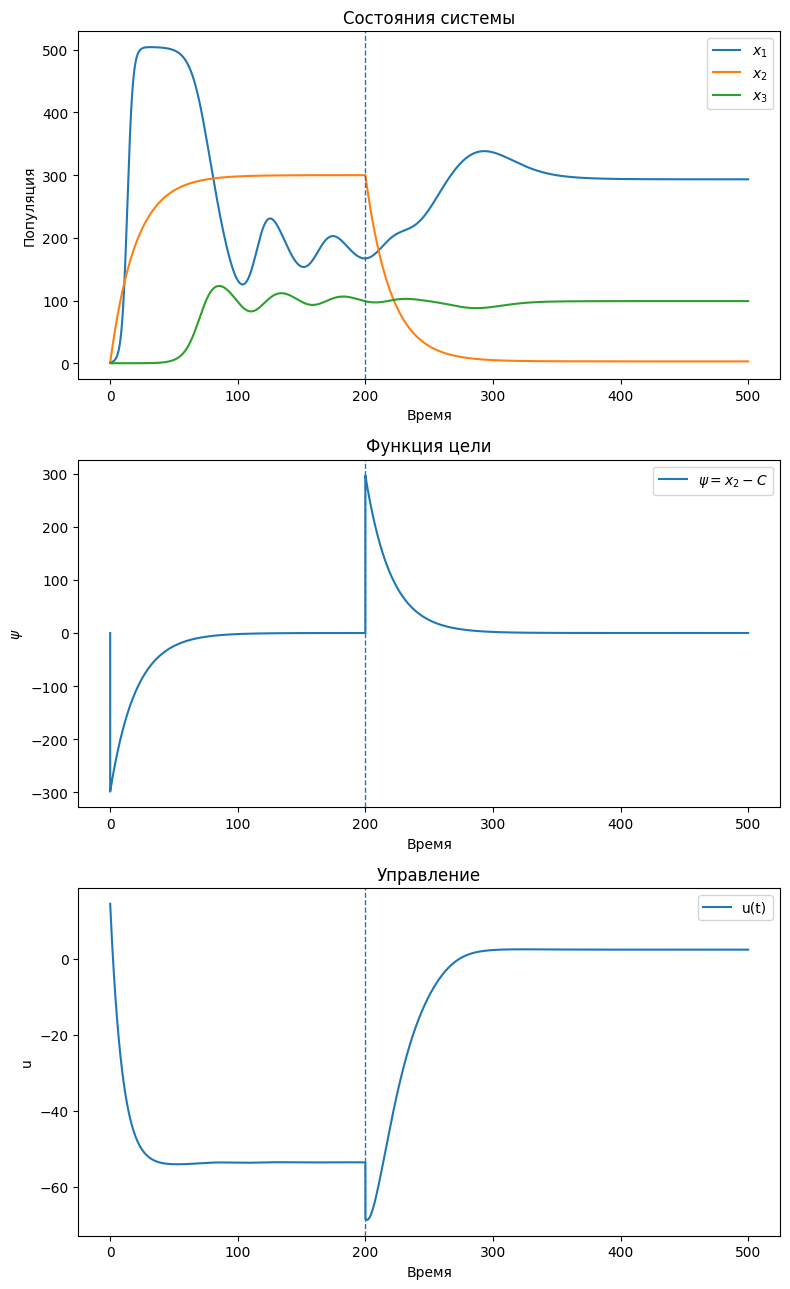

In [ ]:
from sympy import symbols, lambdify
import numpy as np
import matplotlib.pyplot as plt

# возможные переменные
x1_sym, x2_sym, x3_sym, T, T1, a1, a2, b1, C, r1, r2, K1, K2, w1, w2, d1, d2, g1, g2, m, m1 = symbols(
    'x1 x2 x3 T T1 a1 a2 b1 C r1 r2 K1 K2 w1 w2 d1 d2 g1 g2 m m1')

possible_vars = [x1_sym, x2_sym, x3_sym, T, T1, a1, a2, b1, C, r1, r2, K1, K2, w1, w2, d1, d2, g1, g2, m, m1]

u_expr = compute_u(upr_k=2, psi_str="x2 - C")

# Фильтруем переменные, которые есть в u
used_vars = [v for v in possible_vars if v in u_expr.free_symbols]

u_func = lambdify(used_vars, u_expr, modules='numpy')

# численные значения параметров
values_dict = {
    x1_sym: 1,
    x2_sym: 1,
    x3_sym: 0.1,
    T: 20,
    T1: 20,
    a1: 0.002,
    a2: 0.001,
    b1: 0.49,
    C: 300,        # начальное значение C
    r1: 0.4632,
    r2: 0.4425,
    K1: 505,
    K2: 505,
    w1: 0.6625,
    w2: 0.435,
    d1: 45,
    d2: 30,
    g1: 0.516,
    g2: 0.45,
    m: 0.309,
    m1: 0.001
}

dt = 0.01
t = np.arange(0, 500, dt)
x1_vals = np.zeros_like(t)
x2_vals = np.zeros_like(t)
x3_vals = np.zeros_like(t)
psi = np.zeros_like(t)
u_vals = np.zeros_like(t)

x1_vals[0] = 1
x2_vals[0] = 1
x3_vals[0] = 0.1

# одиночный скачок:
t_change = 200.0        # время, при котором C изменится
C_after = 3.0         # новое значение C после t_change


# вспомогательная структура для отрисовки линий смен
change_times = []

for i in range(1, len(t)):
    # обновим состояния в словаре перед вычислениями
    values_dict[x1_sym] = x1_vals[i - 1]
    values_dict[x2_sym] = x2_vals[i - 1]
    values_dict[x3_sym] = x3_vals[i - 1]

    # Обновление C в нужный момент
    current_time = t[i - 1]

    # одиночный скачок
    if current_time >= t_change and values_dict[C] != C_after:
        values_dict[C] = C_after
        change_times.append(t_change)

    args = [values_dict[v] for v in used_vars]
    u_vals[i - 1] = u_func(*args)

    # модель
    dx1 = (
        values_dict[r1] * x1_vals[i - 1] * (1 - (x1_vals[i - 1] + values_dict[a1] * x2_vals[i - 1]) / values_dict[K1])
        - (values_dict[w1] * x1_vals[i - 1] * x3_vals[i - 1]) / (values_dict[d1] + x1_vals[i - 1])

    )

    dx2 = (
        values_dict[r2] * x2_vals[i - 1] * (1 - (x2_vals[i - 1] + values_dict[a2] * x1_vals[i - 1]) / values_dict[K2])
        - (values_dict[w2] * x2_vals[i - 1] * x3_vals[i - 1]) / (values_dict[d2] + values_dict[b1] * x2_vals[i - 1] ** 2)
        + u_vals[i - 1]

    )

    dx3 = (
        (values_dict[g1] * x1_vals[i - 1] * x3_vals[i - 1]) / (values_dict[d1] + x1_vals[i - 1])
        - (values_dict[g2] * x2_vals[i - 1] * x3_vals[i - 1]) / (values_dict[d2] + values_dict[b1] * x2_vals[i - 1] ** 2)
        - values_dict[m] * x3_vals[i - 1]
        - values_dict[m1] * x3_vals[i - 1] ** 2
    )

    x1_vals[i] = max(0, x1_vals[i - 1] + dx1 * dt)
    x2_vals[i] = max(0, x2_vals[i - 1] + dx2 * dt)
    x3_vals[i] = max(0, x3_vals[i - 1] + dx3 * dt)
    psi[i] = x2_vals[i] - values_dict[C]

# финальное значение u
values_dict[x1_sym] = x1_vals[-1]
values_dict[x2_sym] = x2_vals[-1]
values_dict[x3_sym] = x3_vals[-1]
try:
    args = [values_dict[v] for v in used_vars]
    u_vals[-1] = u_func(*args)
except NameError:
    u_vals[-1] = 0.0

print("Последние значения")
print("x1: ", x1_vals[-1])
print("x2: ", x2_vals[-1])
print("x3: ", x3_vals[-1])
print("psi: ", psi[-1])
print("Последнее C:", values_dict[C])

# графики (с вертикальными линиями в местах изменения C)
plt.figure(figsize=(8, 13))

plt.subplot(3, 1, 1)
plt.plot(t, x1_vals, label=r'$x_1$')
plt.plot(t, x2_vals, label=r'$x_2$')
plt.plot(t, x3_vals, label=r'$x_3$')
for ct in sorted(set(change_times)):
    plt.axvline(ct, linestyle='--', linewidth=1)
plt.title('Состояния системы')
plt.xlabel('Время')
plt.ylabel('Популяция')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(t, psi, label=r'$\psi = x_2 - C$')
for ct in sorted(set(change_times)):
    plt.axvline(ct, linestyle='--', linewidth=1)
plt.title('Функция цели')
plt.xlabel('Время')
plt.ylabel(r'$\psi$')
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(t, u_vals, label='u(t)')
for ct in sorted(set(change_times)):
    plt.axvline(ct, linestyle='--', linewidth=1)
plt.title('Управление')
plt.xlabel('Время')
plt.ylabel('u')
plt.legend()

plt.tight_layout()
plt.show()


## цель баланс, управление по x1

Последние значения
x1:  996.5441917583812
x2:  503.2720958790394
x3:  182.88182687375706
psi:  3.0240698833949864e-10


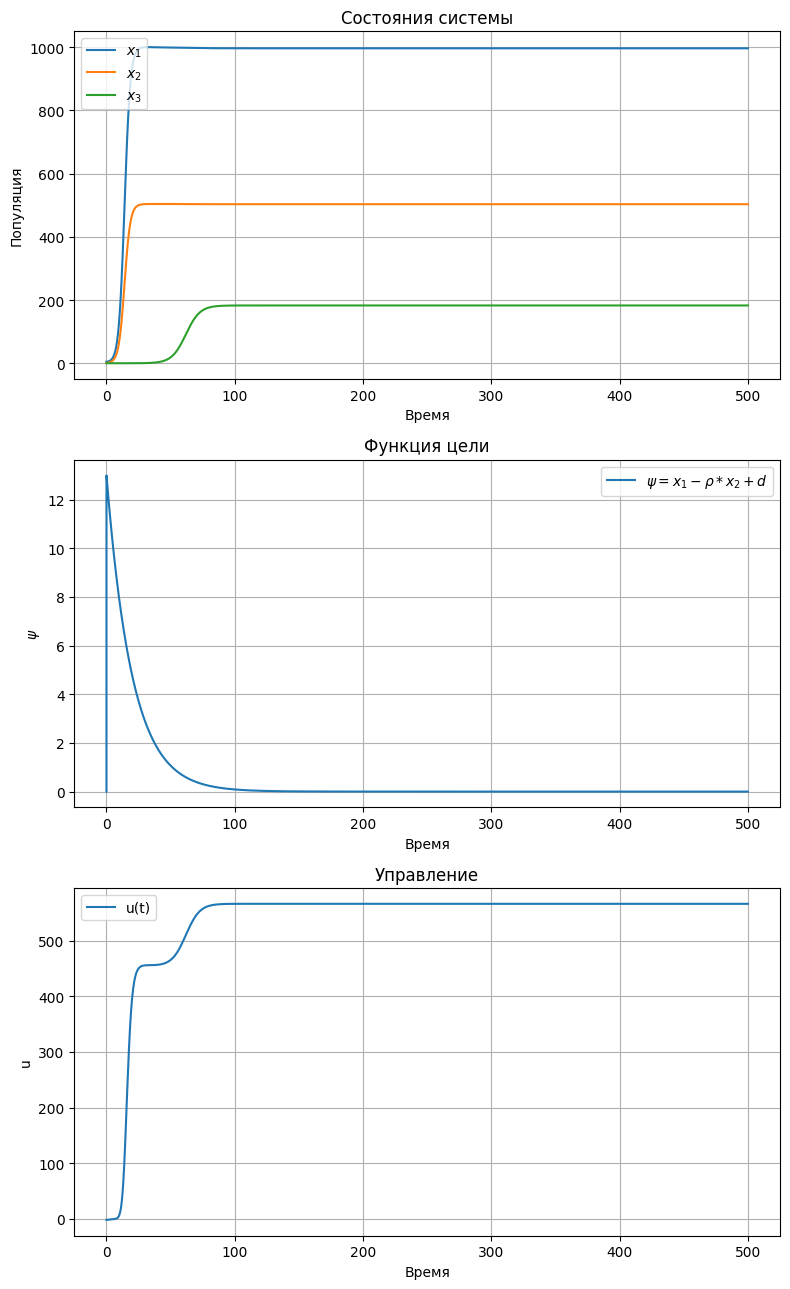

In [ ]:
from sympy import symbols, lambdify
import numpy as np
import matplotlib.pyplot as plt

# возможные переменные
x1_sym, x2_sym, x3_sym, T, T1, a1, a2, b1, C, r1, r2, K1, K2, w1, w2, d1, d2, g1, g2, m, m1, rho, d = symbols('x1 x2 x3 T T1 a1 a2 b1 C r1 r2 K1 K2 w1 w2 d1 d2 g1 g2 m m1 rho d')

possible_vars = [x1_sym, x2_sym, x3_sym, T, T1, a1, a2, b1, C, r1, r2, K1, K2, w1, w2, d1, d2, g1, g2, m, m1, rho, d]

u_expr = compute_u(upr_k=1, psi_str="x1 - rho * x2 + d")

# Фильтруем переменные, которые есть в u
used_vars = [v for v in possible_vars if v in u_expr.free_symbols]

u_func = lambdify(used_vars, u_expr, modules='numpy')

# список значений этих переменных в нужном порядке
# численные значения параметров
values_dict = {
    x1_sym: 5,
    x2_sym: 1,
    x3_sym: 0.1,
    T: 20,
    T1: 20,
    a1: 0.002,
    a2: 0.001,
    b1: 0.49,
    C: 500,
    r1: 0.4632,
    r2: 0.4425,
    K1: 505,
    K2: 505,
    w1: 0.6625,
    w2: 0.435,
    d1: 45,
    d2: 30,
    g1: 0.516,
    g2: 0.45,
    m: 0.309,
    m1: 0.001,
    rho: 2,
    d: 10
}

dt = 0.01
t = np.arange(0, 500, dt)
x1_vals = np.zeros_like(t)
x2_vals = np.zeros_like(t)
x3_vals = np.zeros_like(t)
psi = np.zeros_like(t)
u_vals = np.zeros_like(t)

x1_vals[0] = 5
x2_vals[0] = 1
x3_vals[0] = 0.1

for i in range(1, len(t)):
    # обновим значения переменных в словаре
    values_dict[x1_sym] = x1_vals[i-1]
    values_dict[x2_sym] = x2_vals[i-1]
    values_dict[x3_sym] = x3_vals[i-1]

    # аргументы, в нужном порядке
    args = [values_dict[v] for v in used_vars]

    # вычисляем u
    u_vals[i-1] = u_func(*args)

    # модель
    dx1 = (
        values_dict[r1] * x1_vals[i-1] * (1 - (x1_vals[i-1] + values_dict[a1] * x2_vals[i-1]) / values_dict[K1])
        - (values_dict[w1] * x1_vals[i-1] * x3_vals[i-1]) / (values_dict[d1] + x1_vals[i-1])
        + u_vals[i-1]

    )

    dx2 = (
        values_dict[r2] * x2_vals[i-1] * (1 - (x2_vals[i-1] + values_dict[a2] * x1_vals[i-1]) / values_dict[K2])
        - (values_dict[w2] * x2_vals[i-1] * x3_vals[i-1]) / (values_dict[d2] + values_dict[b1] * x2_vals[i-1] ** 2)

    )

    dx3 = (
        (values_dict[g1] * x1_vals[i-1] * x3_vals[i-1]) / (values_dict[d1] + x1_vals[i-1])
        - (values_dict[g2] * x2_vals[i-1] * x3_vals[i-1]) / (values_dict[d2] + values_dict[b1] * x2_vals[i-1] ** 2)
        - values_dict[m] * x3_vals[i-1]
        - values_dict[m1] * x3_vals[i-1] ** 2
    )


    # x1_vals[i] = max(0, x1_vals[i-1] + dx1 * dt)
    # x2_vals[i] = max(0, x2_vals[i-1] + dx2 * dt)
    # x3_vals[i] = max(0, x3_vals[i-1] + dx3 * dt)

    x1_vals[i] = x1_vals[i-1] + dx1 * dt
    x2_vals[i] = x2_vals[i-1] + dx2 * dt
    x3_vals[i] = x3_vals[i-1] + dx3 * dt

    psi[i] = x1_vals[i] - values_dict[rho] * x2_vals[i] + values_dict[d]

print("Последние значения")
print("x1: ", x1_vals[-1])
print("x2: ", x2_vals[-1])
print("x3: ", x3_vals[-1])
print("psi: ", psi[-1])

# финальное значение u
values_dict[x1_sym] = x1_vals[-1]
values_dict[x2_sym] = x2_vals[-1]
values_dict[x3_sym] = x3_vals[-1]
args = [values_dict[v] for v in used_vars]
u_vals[-1] = u_func(*args)

# графики
plt.figure(figsize=(8, 13))

plt.subplot(3, 1, 1)
plt.plot(t, x1_vals, label=r'$x_1$')
plt.plot(t, x2_vals, label=r'$x_2$')
plt.plot(t, x3_vals, label=r'$x_3$')
#plt.ylim(-5, 550)
plt.title('Состояния системы')
plt.xlabel('Время')
plt.ylabel('Популяция')
plt.legend()
plt.grid()

plt.subplot(3, 1, 2)
plt.plot(t, psi, label=r'$\psi = x_1 - \rho * x_2 + d$')
plt.title('Функция цели')
plt.xlabel('Время')
plt.ylabel(r'$\psi$')
plt.legend()
plt.grid()

plt.subplot(3, 1, 3)
plt.plot(t, u_vals, label='u(t)')
plt.title('Управление')
plt.xlabel('Время')
plt.ylabel('u')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

## управление x1, баланс x2, x3

In [ ]:
from sympy import symbols, lambdify
import numpy as np
import matplotlib.pyplot as plt

# возможные переменные
x1_sym, x2_sym, x3_sym, T, T1, a1, a2, b1, C, r1, r2, K1, K2, w1, w2, d1, d2, g1, g2, m, m1, rho, d = symbols('x1 x2 x3 T T1 a1 a2 b1 C r1 r2 K1 K2 w1 w2 d1 d2 g1 g2 m m1 rho d')

possible_vars = [x1_sym, x2_sym, x3_sym, T, T1, a1, a2, b1, C, r1, r2, K1, K2, w1, w2, d1, d2, g1, g2, m, m1, rho, d]

u_expr = compute_u(upr_k=1, psi_str="x2 - rho * x3 + d")
print('Управление расчитано')

# Фильтруем переменные, которые есть в u
used_vars = [v for v in possible_vars if v in u_expr.free_symbols]

u_func = lambdify(used_vars, u_expr, modules='numpy')

# список значений этих переменных в нужном порядке
# численные значения параметров
values_dict = {
    x1_sym: 5,
    x2_sym: 1,
    x3_sym: 0.1,
    T: 20,
    T1: 20,
    a1: 0.002,
    a2: 0.001,
    b1: 0.49,
    C: 500,
    r1: 0.4632,
    r2: 0.4425,
    K1: 505,
    K2: 505,
    w1: 0.6625,
    w2: 0.435,
    d1: 45,
    d2: 30,
    g1: 0.516,
    g2: 0.45,
    m: 0.309,
    m1: 0.001,
    rho: 0.5,
    d: 10
}

dt = 0.01
t = np.arange(0, 500, dt)
x1_vals = np.zeros_like(t)
x2_vals = np.zeros_like(t)
x3_vals = np.zeros_like(t)
psi = np.zeros_like(t)
u_vals = np.zeros_like(t)

x1_vals[0] = 5
x2_vals[0] = 1
x3_vals[0] = 0.1

for i in range(1, len(t)):
    # обновим значения переменных в словаре
    values_dict[x1_sym] = x1_vals[i-1]
    values_dict[x2_sym] = x2_vals[i-1]
    values_dict[x3_sym] = x3_vals[i-1]

    # аргументы, в нужном порядке
    args = [values_dict[v] for v in used_vars]

    # вычисляем u
    u_vals[i-1] = u_func(*args)

    # модель
    dx1 = (
        values_dict[r1] * x1_vals[i-1] * (1 - (x1_vals[i-1] + values_dict[a1] * x2_vals[i-1]) / values_dict[K1])
        - (values_dict[w1] * x1_vals[i-1] * x3_vals[i-1]) / (values_dict[d1] + x1_vals[i-1])
        + u_vals[i-1]

    )

    dx2 = (
        values_dict[r2] * x2_vals[i-1] * (1 - (x2_vals[i-1] + values_dict[a2] * x1_vals[i-1]) / values_dict[K2])
        - (values_dict[w2] * x2_vals[i-1] * x3_vals[i-1]) / (values_dict[d2] + values_dict[b1] * x2_vals[i-1] ** 2)

    )

    dx3 = (
        (values_dict[g1] * x1_vals[i-1] * x3_vals[i-1]) / (values_dict[d1] + x1_vals[i-1])
        - (values_dict[g2] * x2_vals[i-1] * x3_vals[i-1]) / (values_dict[d2] + values_dict[b1] * x2_vals[i-1] ** 2)
        - values_dict[m] * x3_vals[i-1]
        - values_dict[m1] * x3_vals[i-1] ** 2
    )


    # x1_vals[i] = max(0, x1_vals[i-1] + dx1 * dt)
    # x2_vals[i] = max(0, x2_vals[i-1] + dx2 * dt)
    # x3_vals[i] = max(0, x3_vals[i-1] + dx3 * dt)

    x1_vals[i] = x1_vals[i-1] + dx1 * dt
    x2_vals[i] = x2_vals[i-1] + dx2 * dt
    x3_vals[i] = x3_vals[i-1] + dx3 * dt

    psi[i] = x2_vals[i] - values_dict[rho] * x3_vals[i] + values_dict[d]

print("Последние значения")
print("x1: ", x1_vals[-1])
print("x2: ", x2_vals[-1])
print("x3: ", x3_vals[-1])
print("psi: ", psi[-1])

# финальное значение u
values_dict[x1_sym] = x1_vals[-1]
values_dict[x2_sym] = x2_vals[-1]
values_dict[x3_sym] = x3_vals[-1]
args = [values_dict[v] for v in used_vars]
u_vals[-1] = u_func(*args)

# графики
plt.figure(figsize=(8, 13))

plt.subplot(3, 1, 1)
plt.plot(t, x1_vals, label=r'$x_1$')
plt.plot(t, x2_vals, label=r'$x_2$')
plt.plot(t, x3_vals, label=r'$x_3$')
#plt.ylim(-5, 550)
plt.title('Состояния системы')
plt.xlabel('Время')
plt.ylabel('Популяция')
plt.legend()
plt.grid()

plt.subplot(3, 1, 2)
plt.plot(t, psi, label=r'$\psi = x_2 - \rho * x_3 + d$')
plt.title('Функция цели')
plt.xlabel('Время')
plt.ylabel(r'$\psi$')
plt.legend()
plt.grid()

plt.subplot(3, 1, 3)
plt.plot(t, u_vals, label='u(t)')
plt.title('Управление')
plt.xlabel('Время')
plt.ylabel('u')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()